In [330]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde


## Step 1 — Data Loading & Global Setup
- **Goal:** Load raw VIX daily close data (CBOE, 1990–2026) and configure a consistent plot style.
- **Key output:** `df` — sorted, date-indexed DataFrame with columns `DATE`, `OPEN`, `HIGH`, `LOW`, `CLOSE`.
- **What to look for:** Correct date parsing, trading-day coverage, no missing rows.

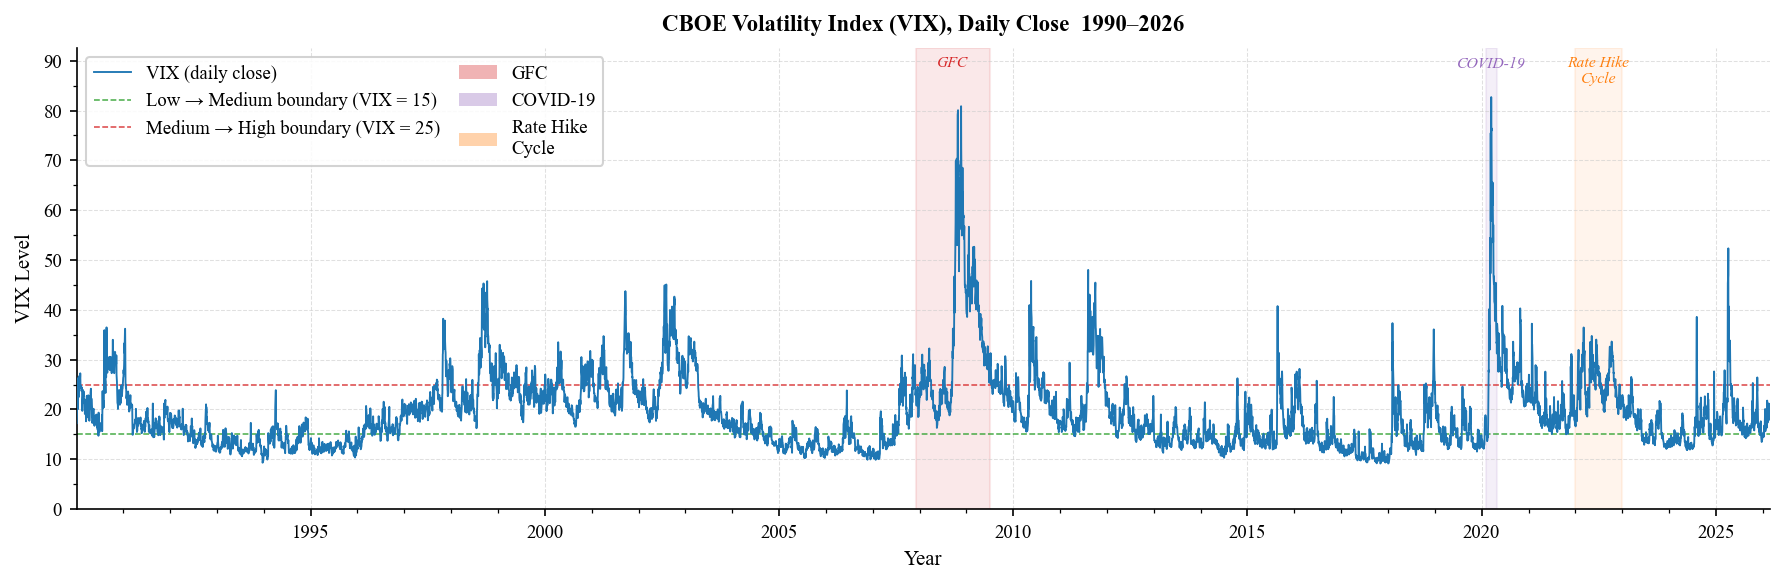

In [331]:

# ── Global style (apply once per session) ───────────────────────────────────
plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.labelsize":    10,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    0.8,
    "axes.grid":         True,
    "grid.color":        "#cccccc",
    "grid.linewidth":    0.5,
    "grid.linestyle":    "--",
    "grid.alpha":        0.6,
    "lines.linewidth":   1.0,
    "figure.dpi":        150,
    "savefig.dpi":       300,
    "savefig.bbox":      "tight",
})

# ── Data (authoritative load — df defined here only) ─────────────────────────
df = pd.read_csv('VIX_history.csv')
df['DATE'] = pd.to_datetime(df['DATE'], format='%m/%d/%Y')
df = df.sort_values('DATE').reset_index(drop=True)

# ── Crisis / event shading  (start, end, label, colour) ──────────────────────
EVENTS = [
    ("2007-12-01", "2009-06-30", "GFC",         "#d62728", 0.10),
    ("2020-02-01", "2020-04-30", "COVID-19",     "#9467bd", 0.10),
    ("2022-01-01", "2022-12-31", "Rate Hike\nCycle", "#ff7f0e", 0.08),
]

# ── Threshold lines (15/25 match the modelling regime boundaries) ─────────────
THRESHOLDS = [
    (15, "#2ca02c", "Low → Medium boundary (VIX = 15)"),
    (25, "#d62728", "Medium → High boundary (VIX = 25)"),
]

# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))          # ~full-page width for A4 report

# Main series
ax.plot(df['DATE'], df['CLOSE'],
        color='#1f77b4', linewidth=0.9, label='VIX (daily close)', zorder=3)

# Pre-compute top-of-chart y for event labels (avoid ylim timing issues)
y_top = df['CLOSE'].max() * 1.10

# Shaded event bands
for start, end, label, colour, alpha in EVENTS:
    ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
               color=colour, alpha=alpha, zorder=1, label=f"_{label}")  # _ hides from legend
    # Text annotation at top of span
    mid = pd.Timestamp(start) + (pd.Timestamp(end) - pd.Timestamp(start)) / 2
    ax.text(mid, y_top,
            label, ha='center', va='top', fontsize=7.5,
            color=colour, fontstyle='italic', clip_on=True)

# Threshold horizontals
for level, colour, lbl in THRESHOLDS:
    ax.axhline(level, color=colour, linewidth=0.75,
               linestyle='--', alpha=0.85, label=lbl, zorder=2)

# ── Axes formatting ───────────────────────────────────────────────────────────
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
ax.yaxis.set_major_locator(mticker.MultipleLocator(10))
ax.yaxis.set_minor_locator(mticker.MultipleLocator(5))

plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

ax.set_xlim(df['DATE'].iloc[0], df['DATE'].iloc[-1])
ax.set_ylim(0, df['CLOSE'].max() * 1.12)

# ── Labels, title, legend ─────────────────────────────────────────────────────
ax.set_title('CBOE Volatility Index (VIX), Daily Close  1990–2026',
             fontweight='bold', pad=8)
ax.set_xlabel('Year')
ax.set_ylabel('VIX Level')

# Combine real legend entries only (skip _ prefixed)
handles, labels = ax.get_legend_handles_labels()
visible = [(h, l) for h, l in zip(handles, labels) if not l.startswith('_')]

# Add manual event patches to legend
event_patches = [Patch(facecolor=c, alpha=0.35, label=lbl)
                 for _, _, lbl, c, _ in EVENTS]
ax.legend(handles=[v[0] for v in visible] + event_patches,
          labels =[v[1] for v in visible] + [p.get_label() for p in event_patches],
          loc='upper left', framealpha=0.85, edgecolor='#cccccc',
          ncol=2, columnspacing=1.0)

plt.tight_layout()
# plt.savefig('vix_timeseries.pdf')   # uncomment to export
plt.show()


In [332]:
# ── VIX regime thresholds and classifier (used throughout notebook) ─────
LOW_THRESH  = 15
HIGH_THRESH = 25

def label_regime(series):
    """Map VIX levels → Low (≤ 15) / Medium (15–25] / High (> 25)."""
    return pd.cut(
        series,
        bins=[-np.inf, LOW_THRESH, HIGH_THRESH, np.inf],
        labels=['Low', 'Medium', 'High'],
    )


In [333]:
# ── Data quality checks: missingness, duplicates, gaps ─────────────────────
# Missingness summary
missing = df.isna().sum().sort_values(ascending=False)
print("Missing values per column (top):")
print(missing[missing > 0] if (missing > 0).any() else "None")

# Duplicate date check (should be zero for daily trading data)
dup_dates = df['DATE'].duplicated().sum()
print(f"Duplicate DATE rows: {dup_dates}")

# Gap check (largest gaps in calendar days; weekends/holidays are expected)
gap_days = df['DATE'].diff().dt.days
print("Largest calendar gaps (days):")
print(gap_days.sort_values(ascending=False).head(10))

# Simple missingness bar (if any)
if (missing > 0).any():
    plt.figure(figsize=(8,3))
    missing[missing>0].plot(kind='bar')
    plt.title("Missingness by column")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


Missing values per column (top):
None
Duplicate DATE rows: 0
Largest calendar gaps (days):
2950    7.0
5752    5.0
4284    5.0
4799    4.0
2269    4.0
2273    4.0
2283    4.0
7336    4.0
3699    4.0
2302    4.0
Name: DATE, dtype: float64


## Step 2 — Exploratory Data Analysis (EDA)
- **Goal:** Characterise VIX distribution, autocorrelation structure, regime balance, and volatility dynamics.
- **Key outputs:** Time-series plot with crisis bands and 15/25 thresholds, autocorrelation chart, distribution KDE, class-balance bar chart, rolling mean/std.
- **What to look for:** Lag-1 ACF > 0.98 (strong persistence); right-skewed distribution; regime split ≈ Low 32 % / Medium 50 % / High 17 %.

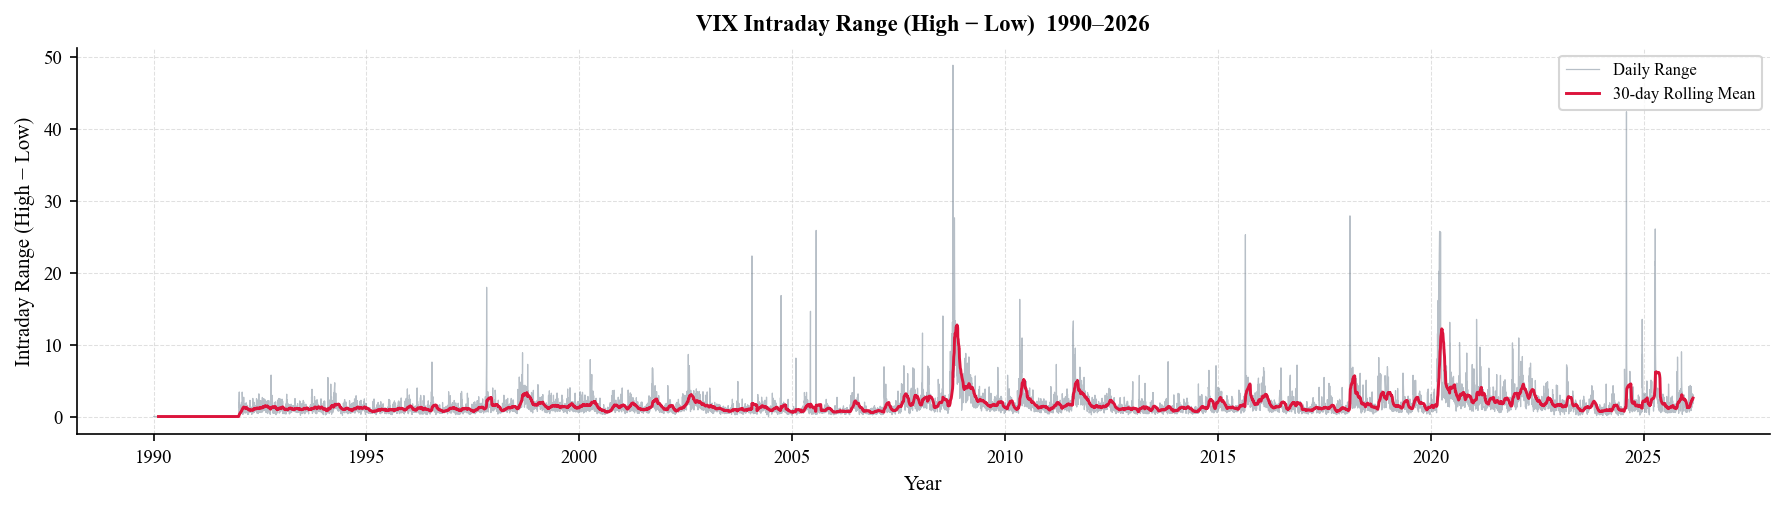

In [334]:

# ── Intraday Range (High − Low) — EDA only; no df mutation ───────────────────
_range    = df["HIGH"] - df["LOW"]
_range_30 = _range.rolling(30).mean()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(df["DATE"], _range,    color="slategray", linewidth=0.6, alpha=0.5, label="Daily Range")
ax.plot(df["DATE"], _range_30, color="crimson",   linewidth=1.4, label="30-day Rolling Mean")
ax.set_ylabel("Intraday Range (High − Low)")
ax.set_xlabel("Year")
ax.set_title("VIX Intraday Range (High − Low)  1990–2026", fontweight="bold", pad=8)
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()
# NOTE: _range and _range_30 are local to this cell; df is not mutated.
# RANGE/range_30d are not used in any downstream modelling cell.


In [335]:
# Proportion under economic thresholds (FULL DATA — exploratory only)

calm = (df["CLOSE"] <= 15).mean()
mid = ((df["CLOSE"] > 15) & (df["CLOSE"] <= 25)).mean()
stress = (df["CLOSE"] > 25).mean()

print("Calm (<15):", round(calm, 3))
print("Uncertain (15–25):", round(mid, 3))
print("Stress (>25):", round(stress, 3))

Calm (<15): 0.324
Uncertain (15–25): 0.502
Stress (>25): 0.174


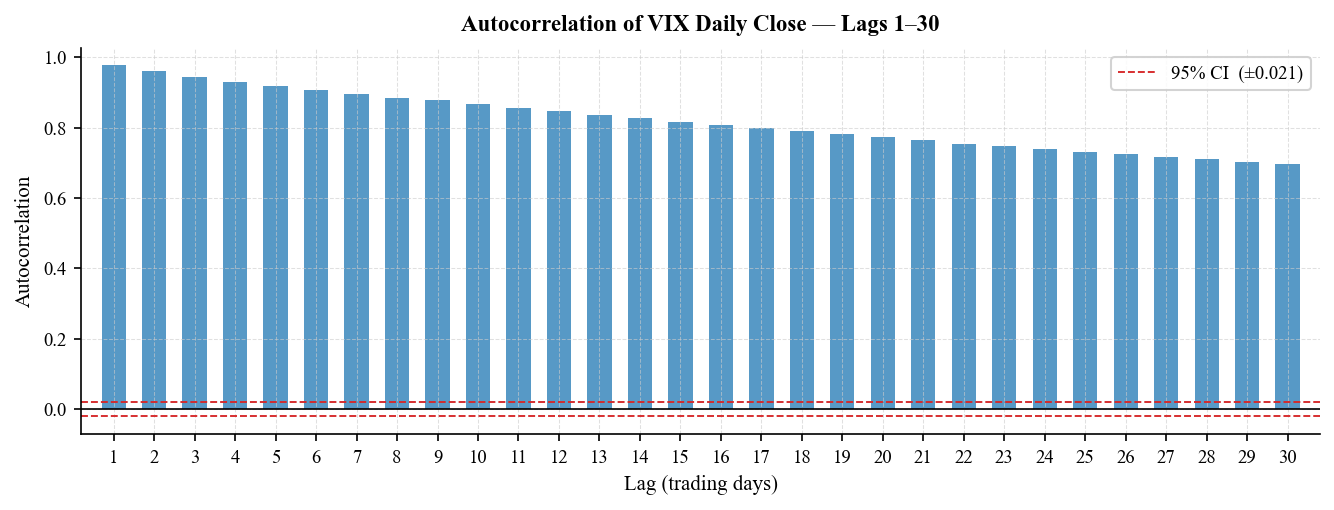

In [336]:

# ── 1. Autocorrelation of VIX CLOSE — Lags 1–30 ──────────────────────────────
lags     = list(range(1, 31))
acf_vals = [df['CLOSE'].autocorr(lag=k) for k in lags]

n  = len(df)
ci = 1.96 / (n ** 0.5)          # 95% Bartlett confidence bound (≈ ±0.021 here)

fig, ax = plt.subplots(figsize=(9, 3.5))

# Bar chart of ACF values
ax.bar(lags, acf_vals, color='#1f77b4', alpha=0.75, width=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline( ci, color='#d62728', linestyle='--', linewidth=0.9, label=f'95% CI  (±{ci:.3f})')
ax.axhline(-ci, color='#d62728', linestyle='--', linewidth=0.9)

ax.set_xlabel('Lag (trading days)')
ax.set_ylabel('Autocorrelation')
ax.set_title('Autocorrelation of VIX Daily Close — Lags 1–30', fontweight='bold', pad=8)
ax.set_xticks(lags)
ax.set_xlim(0.2, 30.8)
ax.legend(loc='upper right', framealpha=0.85)

plt.tight_layout()
plt.show()


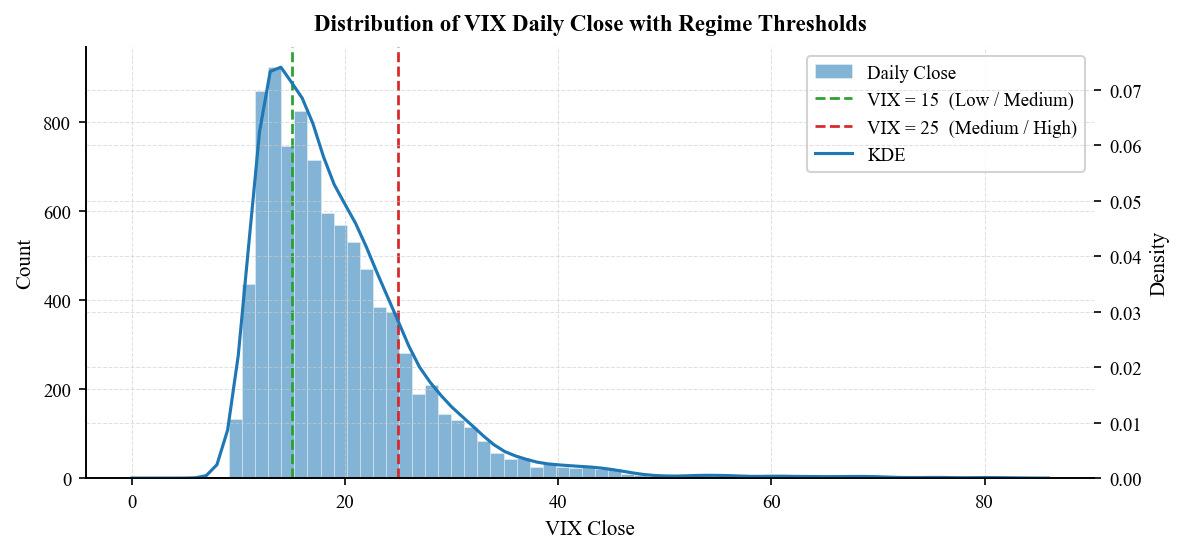

In [337]:

# ── 2. Distribution of VIX CLOSE with 15 / 25 Regime Thresholds ──────────────
fig, ax1 = plt.subplots(figsize=(8, 3.8))
ax2 = ax1.twinx()

# Histogram (left axis)
ax1.hist(df['CLOSE'], bins=60, color='#1f77b4', alpha=0.55,
         edgecolor='white', linewidth=0.3, label='Daily Close')

# KDE overlay (right axis)
kde_x = pd.Series(range(0, int(df['CLOSE'].max()) + 5)) / 1.0
kde   = gaussian_kde(df['CLOSE'].dropna())
ax2.plot(kde_x, kde(kde_x), color='#1f77b4', linewidth=1.5, label='KDE')
ax2.set_ylabel('Density')
ax2.set_ylim(bottom=0)
ax2.spines['top'].set_visible(False)

# Threshold verticals
ax1.axvline(15, color='#2ca02c', linestyle='--', linewidth=1.3,
            label='VIX = 15  (Low / Medium)')
ax1.axvline(25, color='#d62728', linestyle='--', linewidth=1.3,
            label='VIX = 25  (Medium / High)')

ax1.set_xlabel('VIX Close')
ax1.set_ylabel('Count')
ax1.set_title('Distribution of VIX Daily Close with Regime Thresholds',
              fontweight='bold', pad=8)

# Merge legends from both axes
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper right', framealpha=0.85)

plt.tight_layout()
plt.show()


VIX CLOSE quantiles:
0.500    17.58000
0.900    28.58000
0.950    33.00350
0.990    46.77520
0.995    57.23525
0.999    71.78123
Name: CLOSE, dtype: float64

Top 10 VIX CLOSE days:
      DATE  CLOSE
2020-03-16  82.69
2008-11-20  80.86
2008-10-27  80.06
2008-10-24  79.13
2020-03-18  76.45
2020-03-17  75.91
2020-03-12  75.47
2008-11-19  74.26
2008-11-21  72.67
2020-03-19  72.00


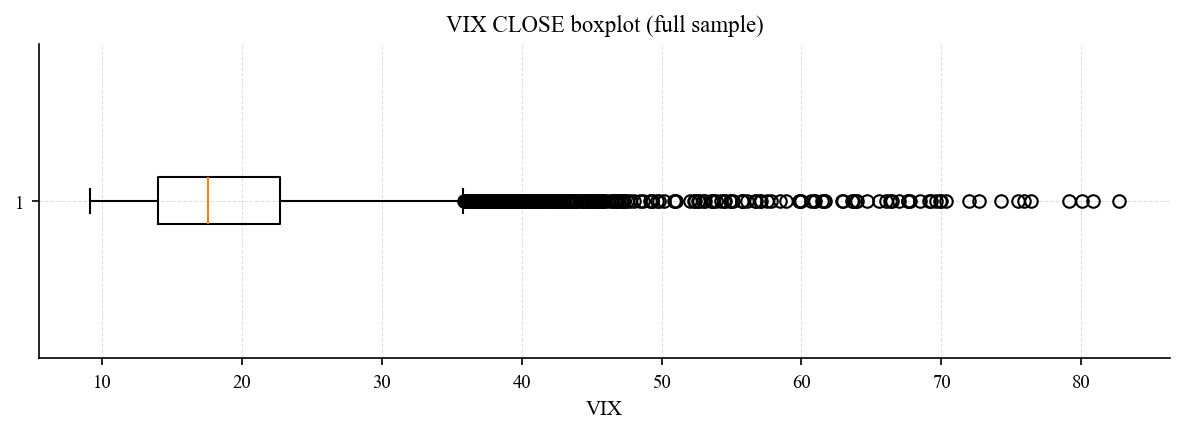

In [338]:
# ── Outlier quantification: extreme VIX days ───────────────────────────────
q = df['CLOSE'].quantile([0.50, 0.90, 0.95, 0.99, 0.995, 0.999])
print("VIX CLOSE quantiles:")
print(q)

top = df.nlargest(10, 'CLOSE')[['DATE','CLOSE']]
print("\nTop 10 VIX CLOSE days:")
print(top.to_string(index=False))

plt.figure(figsize=(8,3))
plt.boxplot(df['CLOSE'].dropna(), vert=False)
plt.title("VIX CLOSE boxplot (full sample)")
plt.xlabel("VIX")
plt.tight_layout()
plt.show()


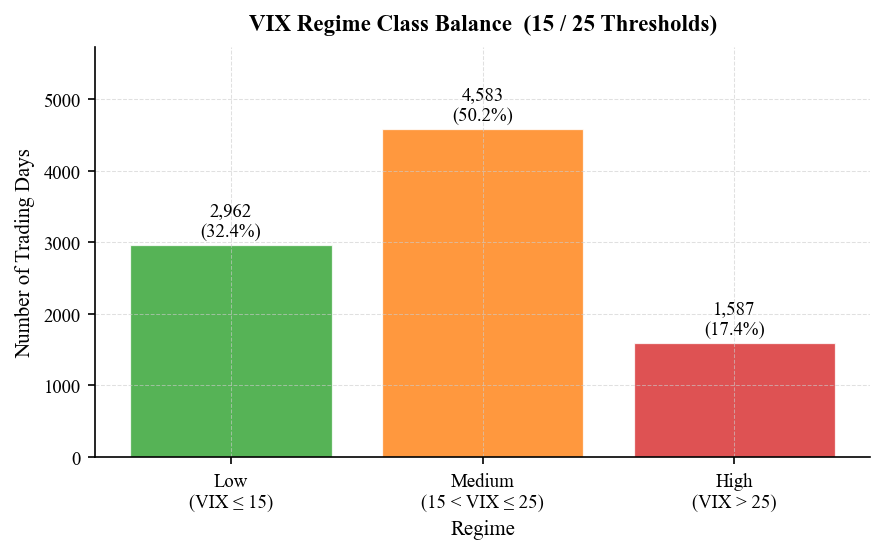

In [339]:
# ── 3. Class Balance — Low / Medium / High Volatility Regimes ────────────────
bins    = [-np.inf, 15, 25, np.inf]
labels  = ['Low\n(VIX ≤ 15)', 'Medium\n(15 < VIX ≤ 25)', 'High\n(VIX > 25)']
colours = ['#2ca02c', '#ff7f0e', '#d62728']

regime_series = pd.cut(df['CLOSE'], bins=bins, labels=labels)
regime_counts = regime_series.value_counts().reindex(labels)
total         = regime_counts.sum()

fig, ax = plt.subplots(figsize=(6, 3.8))
bars = ax.bar(labels, regime_counts.values, color=colours, alpha=0.80,
              edgecolor='white', linewidth=0.6)
for bar, count in zip(bars, regime_counts.values):
    pct = count / total * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + regime_counts.max() * 0.015,
            f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('Number of Trading Days')
ax.set_title('VIX Regime Class Balance  (15 / 25 Thresholds)', fontweight='bold', pad=8)
ax.set_ylim(0, regime_counts.max() * 1.25)
ax.set_xlabel('Regime')
plt.tight_layout()
plt.show()


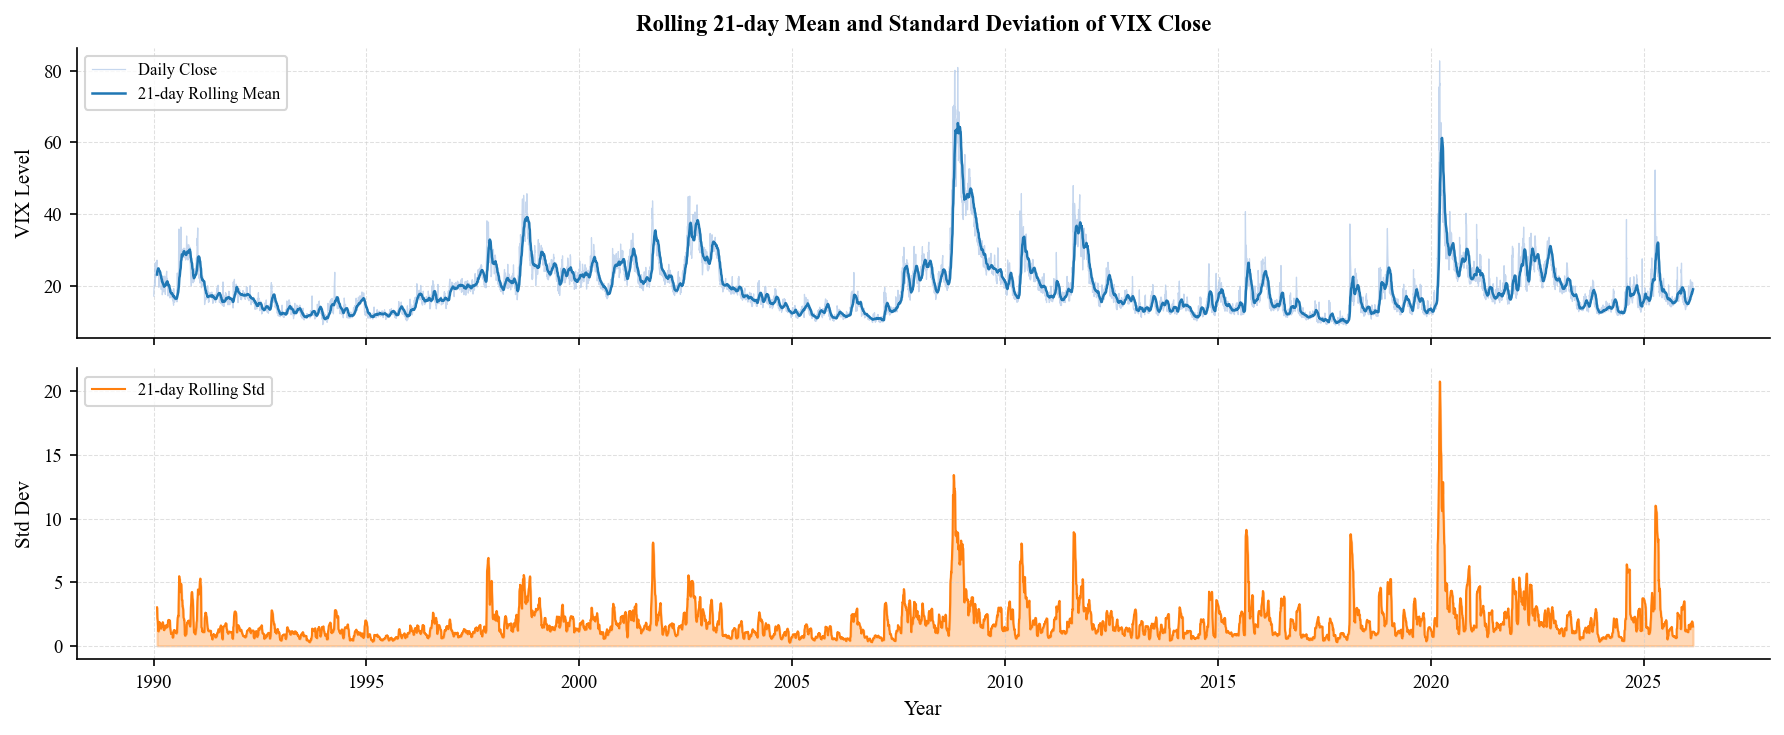

In [340]:

# ── 4. Rolling 21-day Mean and Standard Deviation of VIX CLOSE ───────────────
# NOTE: EDA only — rolling windows here include today's close (no shift applied).
#       Model features use CLOSE.shift(1).rolling(21) to avoid look-ahead leakage.
roll_mean = df['CLOSE'].rolling(21).mean()
roll_std  = df['CLOSE'].rolling(21).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

# Mean panel
axes[0].plot(df['DATE'], df['CLOSE'],  color='#aec7e8', linewidth=0.6, alpha=0.7, label='Daily Close')
axes[0].plot(df['DATE'], roll_mean,    color='#1f77b4', linewidth=1.2, label='21-day Rolling Mean')
axes[0].set_ylabel('VIX Level')
axes[0].set_title('Rolling 21-day Mean and Standard Deviation of VIX Close',
                  fontweight='bold', pad=8)
axes[0].legend(fontsize=8, loc='upper left')

# Std panel
axes[1].fill_between(df['DATE'], roll_std, alpha=0.30, color='#ff7f0e')
axes[1].plot(df['DATE'], roll_std, color='#ff7f0e', linewidth=1.0, label='21-day Rolling Std')
axes[1].set_ylabel('Std Dev')
axes[1].set_xlabel('Year')
axes[1].legend(fontsize=8, loc='upper left')

axes[0].xaxis.set_major_locator(mdates.YearLocator(5))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.tight_layout()
plt.show()


## Step 3 — Feature Engineering
- **Goal:** Construct 9 leakage-free features using only information observable at close of day *t*; label is next day's regime (CLOSE shifted −1).
- **Key output:** `df_ml` with target `regime_t1` and features: lagged closes, log-returns, rolling mean/std, VIX-vs-MA21, lagged regime.
- **What to look for:** Leakage sanity check — `regime_t1 == current_regime` ≈ 80–90 % (natural persistence), **not** ≈ 100 %.

P(Regime_{t+1} | Regime_t):
CLOSE     Low  Medium   High
CLOSE                       
Low     0.927   0.073  0.000
Medium  0.047   0.917  0.036
High    0.000   0.103  0.897


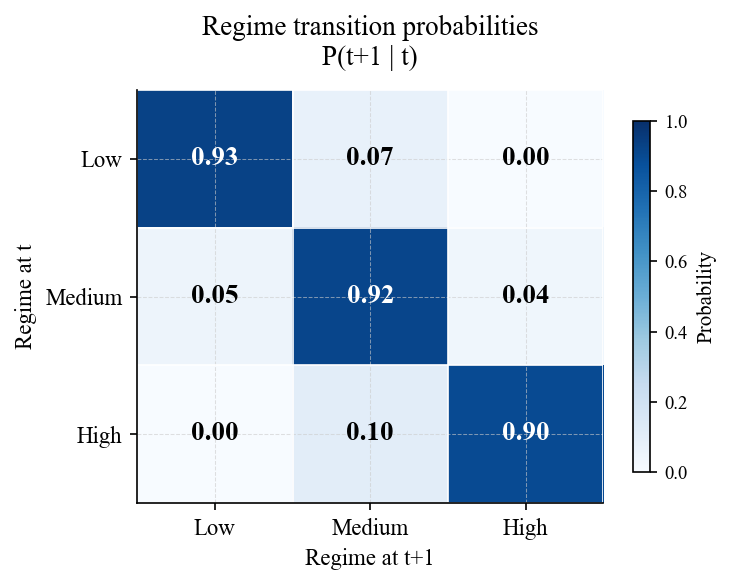

In [341]:
# ── Regime transition matrix (empirical probabilities) ─────────────────────
_bins = [-np.inf, 15, 25, np.inf]
_lbls = ['Low', 'Medium', 'High']
regime_t  = pd.cut(df['CLOSE'],             bins=_bins, labels=_lbls)
regime_t1 = pd.cut(df['CLOSE'].shift(-1),   bins=_bins, labels=_lbls)

trans = pd.crosstab(regime_t, regime_t1, normalize='index')
print("P(Regime_{t+1} | Regime_t):")
print(trans.round(3))

plt.figure(figsize=(5, 4))
im = plt.imshow(trans.values, cmap="Blues", vmin=0, vmax=1, aspect='auto')
plt.xticks(range(len(trans.columns)), trans.columns, fontsize=11)
plt.yticks(range(len(trans.index)), trans.index, fontsize=11)
plt.colorbar(im, label="Probability", shrink=0.85)
plt.title("Regime transition probabilities\nP(t+1 | t)", fontsize=13, pad=12)
plt.xlabel("Regime at t+1", fontsize=11)
plt.ylabel("Regime at t", fontsize=11)

# Add grid lines between cells
for x in [-0.5, 0.5, 1.5, 2.5]:
    plt.axvline(x, color='white', linewidth=0.8)
    plt.axhline(x, color='white', linewidth=0.8)

# Annotations — white text on dark cells, black on light
for i in range(trans.shape[0]):
    for j in range(trans.shape[1]):
        val = trans.values[i, j]
        color = "white" if val > 0.5 else "black"
        plt.text(j, i, f"{val:.2f}", ha='center', va='center',
                 fontsize=13, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

In [342]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 2 — Feature Engineering  (strict no look-ahead)
# ══════════════════════════════════════════════════════════════════════════════

LOW_THRESH  = 15
HIGH_THRESH = 25

df_feat = df.copy()

def label_regime(series):
    """Map VIX levels → Low (≤15) / Medium (15–25] / High (>25)."""
    return pd.cut(
        series,
        bins=[-np.inf, LOW_THRESH, HIGH_THRESH, np.inf],
        labels=['Low', 'Medium', 'High'],
    )

# Target: NEXT day's regime
df_feat['regime_t1']      = label_regime(df_feat['CLOSE'].shift(-1))

# Features (all known at close of day t)
df_feat['lag1_close']     = df_feat['CLOSE'].shift(1)
df_feat['lag2_close']     = df_feat['CLOSE'].shift(2)
df_feat['lag5_close']     = df_feat['CLOSE'].shift(5)
df_feat['ret_1d']         = np.log(df_feat['CLOSE'] / df_feat['CLOSE'].shift(1))
df_feat['ret_5d']         = np.log(df_feat['CLOSE'] / df_feat['CLOSE'].shift(5))
df_feat['roll_mean_21']   = df_feat['CLOSE'].shift(1).rolling(21).mean()
df_feat['roll_std_21']    = df_feat['CLOSE'].shift(1).rolling(21).std()
df_feat['vix_vs_ma21']    = df_feat['CLOSE'].shift(1) - df_feat['roll_mean_21']
df_feat['current_regime'] = label_regime(df_feat['lag1_close'])

FEATURE_COLS = [
    'lag1_close', 'lag2_close', 'lag5_close',
    'ret_1d', 'ret_5d',
    'roll_mean_21', 'roll_std_21', 'vix_vs_ma21',
    'current_regime',
]
TARGET_COL = 'regime_t1'

df_ml = (
    df_feat.dropna(subset=FEATURE_COLS + [TARGET_COL])
           .copy()
           .reset_index(drop=True)
)

print(f"Rows retained : {len(df_ml):,}   (dropped {len(df_feat)-len(df_ml):,})")
vc = df_ml[TARGET_COL].value_counts().reindex(['Low', 'Medium', 'High'])
for lbl, cnt in vc.items():
    print(f"  {lbl:8s}  {cnt:5,}  ({cnt/len(df_ml)*100:.1f} %)")

pct_same = (df_ml['regime_t1'] == df_ml['current_regime']).mean()
print(f"\nSanity check — regime_t1 == current_regime : {pct_same:.1%}  (expect 85-92%,  see transition matrix Cell 14)")
print(f"ML dataset shape: {df_ml.shape}   Features: {len(FEATURE_COLS)}")
assert pct_same < 0.99, "Near-perfect match — potential target leakage!"
print("Leakage check passed.")


Rows retained : 9,110   (dropped 22)
  Low       2,962  (32.5 %)
  Medium    4,569  (50.2 %)
  High      1,579  (17.3 %)

Sanity check — regime_t1 == current_regime : 88.7%  (expect 85-92%,  see transition matrix Cell 14)
ML dataset shape: (9110, 15)   Features: 9
Leakage check passed.


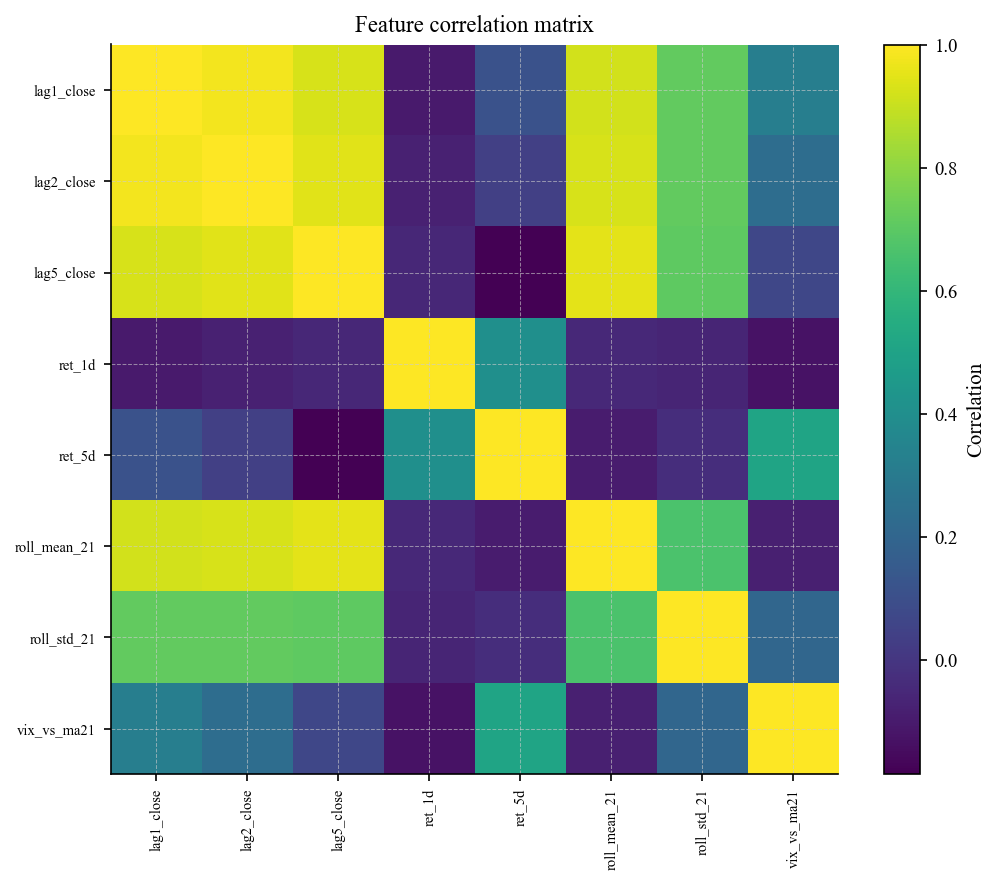

In [343]:
# ── Feature correlation matrix (multicollinearity check) ───────────────────
# Use the modelling frame (after dropping NaNs)
corr = df_ml[FEATURE_COLS].corr(numeric_only=True)

plt.figure(figsize=(7,6))
plt.imshow(corr.values, aspect='auto')
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90, fontsize=7)
plt.yticks(range(len(corr.index)), corr.index, fontsize=7)
plt.colorbar(label="Correlation")
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


### Step 3b — Chronological Split & Feature Scaling
- **Goal:** Partition `df_ml` chronologically (no shuffle) into Train 70 % / Val 15 % / Test 15 %; fit `StandardScaler` on train only.
- **Key outputs:** `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.
- **What to look for:** Test set covers Oct 2020 – Feb 2026 (post-COVID); no date overlap between splits confirmed by assertion.

In [344]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 3 — Chronological 70 / 15 / 15 Split  +  Feature Scaling
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.preprocessing import StandardScaler

# ── Ordinal-encode the categorical feature before scaling ─────────────────────
# Low=0, Medium=1, High=2  (preserves natural order, compatible with LR + RF)
REGIME_ORDER = {'Low': 0, 'Medium': 1, 'High': 2}
# convert to integer explicitly to avoid category dtype
df_ml['current_regime_enc'] = df_ml['current_regime'].map(REGIME_ORDER).astype(int)

# Numeric feature list (ordinal-encoded categorical replaces the string column)
# NOTE: do not include the string-valued `current_regime` here; use
#       `current_regime_enc` (integer) instead to avoid dtype errors.
NUM_FEATURES = [
    'lag1_close', 'lag2_close', 'lag5_close',
    'ret_1d', 'ret_5d',
    'roll_mean_21', 'roll_std_21', 'vix_vs_ma21',
    'current_regime_enc',
]

assert all(pd.api.types.is_numeric_dtype(df_ml[col]) for col in NUM_FEATURES)
print("✓ All features numeric — dtype check passed.")

# Human-readable names for Step 6 importance chart
FEAT_DISPLAY = [
    'lag1_close', 'lag2_close', 'lag5_close',
    'ret_1d', 'ret_5d',
    'roll_mean_21', 'roll_std_21', 'vix_vs_ma21',
    'current_regime',
]

CLASS_ORDER = ['Low', 'Medium', 'High']

# ── Chronological split (no shuffle — time series integrity) ──────────────────
n       = len(df_ml)
n_train = int(n * 0.70)
n_val   = int(n * 0.15)
n_test  = n - n_train - n_val          # remainder → no rounding gap

train = df_ml.iloc[:n_train].copy()
val   = df_ml.iloc[n_train : n_train + n_val].copy()
test  = df_ml.iloc[n_train + n_val :].copy()

print("Chronological split:")
print(f"  Train : {len(train):5,} rows   "
      f"{train['DATE'].iloc[0].date()} → {train['DATE'].iloc[-1].date()}")
print(f"  Val   : {len(val):5,} rows   "
      f"{val['DATE'].iloc[0].date()} → {val['DATE'].iloc[-1].date()}")
print(f"  Test  : {len(test):5,} rows   "
      f"{test['DATE'].iloc[0].date()} → {test['DATE'].iloc[-1].date()}")

# Sanity: no date overlap between splits
assert train['DATE'].iloc[-1] < val['DATE'].iloc[0],  "Train/Val dates overlap!"
assert val['DATE'].iloc[-1]   < test['DATE'].iloc[0], "Val/Test dates overlap!"
print("Date-order sanity check passed.\n")

# ── StandardScaler: FIT on train only, TRANSFORM val and test ─────────────────
scaler  = StandardScaler()
X_train = scaler.fit_transform(train[NUM_FEATURES])   # fit + transform
X_val   = scaler.transform(val[NUM_FEATURES])         # transform only — no fit
X_test  = scaler.transform(test[NUM_FEATURES])        # transform only — no fit

y_train = train[TARGET_COL].astype(str).values
y_val   = val[TARGET_COL].astype(str).values
y_test  = test[TARGET_COL].astype(str).values

print(f"Scaler fit on train only (mean ± std from {train['DATE'].iloc[0].date()}"
      f" to {train['DATE'].iloc[-1].date()}).")
print(f"Shapes — X_train: {X_train.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")


✓ All features numeric — dtype check passed.
Chronological split:
  Train : 6,377 rows   1990-01-31 → 2015-05-27
  Val   : 1,366 rows   2015-05-28 → 2020-10-27
  Test  : 1,367 rows   2020-10-28 → 2026-02-26
Date-order sanity check passed.

Scaler fit on train only (mean ± std from 1990-01-31 to 2015-05-27).
Shapes — X_train: (6377, 9), X_val: (1366, 9), X_test: (1367, 9)


In [345]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 4a — Metric Imports + Evaluation Helper  (must run before Step 4)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.metrics import (
    accuracy_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
)

def eval_metrics(y_true, y_pred, model_name):
    acc = accuracy_score(y_true, y_pred)
    mf1 = f1_score(y_true, y_pred, labels=CLASS_ORDER, average='macro',  zero_division=0)
    pf1 = f1_score(y_true, y_pred, labels=CLASS_ORDER, average=None,     zero_division=0)
    return {'Model': model_name, 'Accuracy': acc, 'Macro F1': mf1,
            'F1-Low': pf1[0], 'F1-Med': pf1[1], 'F1-High': pf1[2]}

# Label encoding for models that require integer targets (e.g., XGBoost, PyTorch)
LABEL_TO_INT = {'Low': 0, 'Medium': 1, 'High': 2}
INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}


## Step 4 — Persistence Baseline
- **Goal:** Establish a naive benchmark — predict tomorrow's regime = today's observed regime (no model required).
- **Key output:** `y_pred_persist`, `metrics_persist` (Accuracy, Macro F1, per-class F1).
- **What to look for:** High baseline macro F1 (~0.88) driven by regime autocorrelation — all ML models must exceed this to demonstrate added value.

── Persistence Baseline  (test set) ──
  Accuracy  : 0.9056
  Macro F1  : 0.8799
  F1-Low   : 0.8860
  F1-Medium: 0.9286
  F1-High  : 0.8251


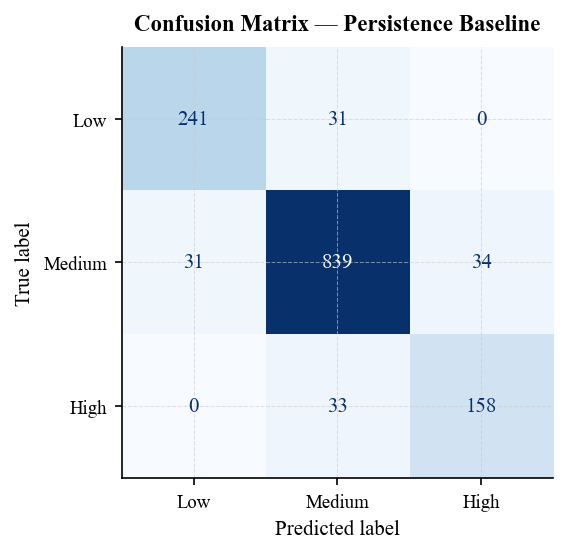

In [346]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 4 — Persistence Baseline
# ══════════════════════════════════════════════════════════════════════════════

# Persistence: at close of day t, today's regime IS observable (CLOSE is known).
# Predict: regime_t1 = label_regime(CLOSE[t])  — no leakage, CLOSE is a feature input.
y_pred_persist = label_regime(test['CLOSE']).astype(str).values

acc_p = accuracy_score(y_test, y_pred_persist)
mf1_p = f1_score(y_test, y_pred_persist, labels=CLASS_ORDER, average='macro', zero_division=0)
pf1_p = f1_score(y_test, y_pred_persist, labels=CLASS_ORDER, average=None,    zero_division=0)

print("── Persistence Baseline  (test set) ──")
print(f"  Accuracy  : {acc_p:.4f}")
print(f"  Macro F1  : {mf1_p:.4f}")
for cls, f1 in zip(CLASS_ORDER, pf1_p):
    print(f"  F1-{cls:6s}: {f1:.4f}")

cm_p = confusion_matrix(y_test, y_pred_persist, labels=CLASS_ORDER)
fig, ax = plt.subplots(figsize=(4.5, 3.8))
ConfusionMatrixDisplay(cm_p, display_labels=CLASS_ORDER).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Persistence Baseline', fontweight='bold', pad=8)
plt.tight_layout()
plt.show()

metrics_persist = eval_metrics(y_test, y_pred_persist, 'Persistence')


## Step 5 — Machine Learning Models
- **Goal:** Train five classifiers (LR, RF, XGBoost, sklearn MLP, PyTorch DeepMLP); tune each on val set via macro F1 grid search.
- **Key outputs:** `y_pred_lr`, `y_pred_rf`, `y_pred_xgb`, `y_pred_mlp`; corresponding `metrics_*` dicts.
- **What to look for:** All hyperparameter choices made on val set only; test set touched **once** for final evaluation.

── LR: C grid search on val set ──
  C=   0.001   val macro-F1 = 0.8421 ←
  C=   0.010   val macro-F1 = 0.8741 ←
  C=   0.100   val macro-F1 = 0.8872 ←
  C=   1.000   val macro-F1 = 0.8930 ←
  C=  10.000   val macro-F1 = 0.8985 ←
  C= 100.000   val macro-F1 = 0.8967

Best C = 10.0   test macro-F1 = 0.8821

── RF: n_estimators × max_depth grid search on val set ──
  n_est=100  max_depth=None   val macro-F1 = 0.8851 ←
  n_est=100  max_depth=5      val macro-F1 = 0.8764
  n_est=100  max_depth=10     val macro-F1 = 0.8854 ←
  n_est=100  max_depth=20     val macro-F1 = 0.8844
  n_est=200  max_depth=None   val macro-F1 = 0.8837
  n_est=200  max_depth=5      val macro-F1 = 0.8754
  n_est=200  max_depth=10     val macro-F1 = 0.8845
  n_est=200  max_depth=20     val macro-F1 = 0.8854 ←
  n_est=300  max_depth=None   val macro-F1 = 0.8868 ←
  n_est=300  max_depth=5      val macro-F1 = 0.8754
  n_est=300  max_depth=10     val macro-F1 = 0.8852
  n_est=300  max_depth=20     val macro-F1 = 0.8862

B

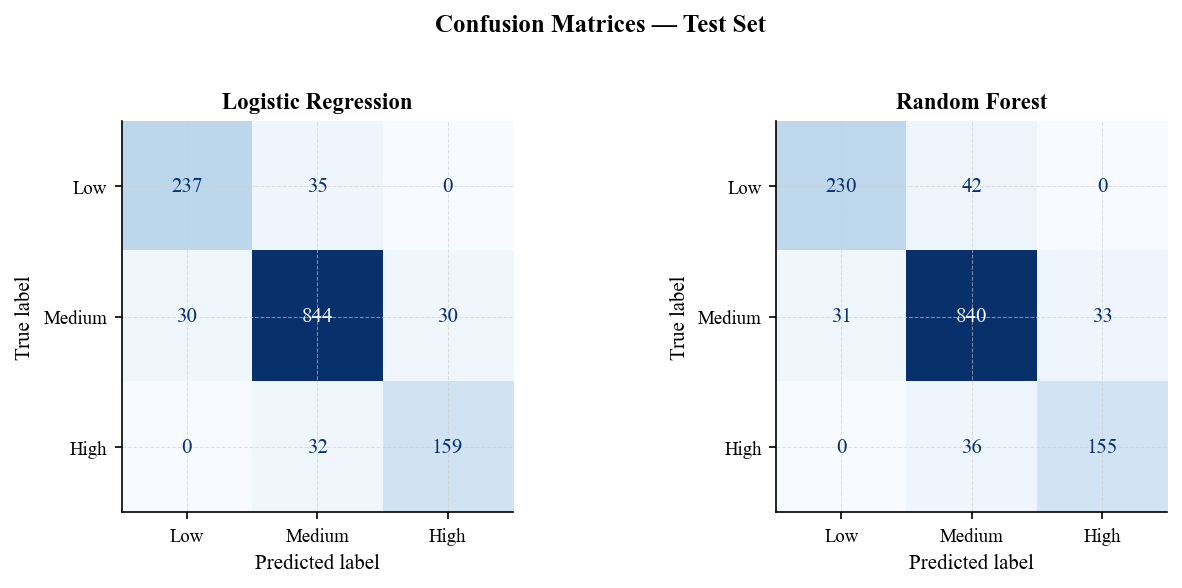

In [347]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 5 — Models: Logistic Regression + Random Forest  (tuned on val set)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble      import RandomForestClassifier
from itertools             import product

# ── 5a. Logistic Regression — tune C on val set ───────────────────────────────
print("── LR: C grid search on val set ──")
best_C, best_lr_vf1 = None, -1

for C in [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]:
    lr  = LogisticRegression(C=C, max_iter=2000, solver='lbfgs', random_state=42)
    lr.fit(X_train, y_train)
    vf1 = f1_score(y_val, lr.predict(X_val), labels=CLASS_ORDER,
                   average='macro', zero_division=0)
    mark = ' ←' if vf1 > best_lr_vf1 else ''
    print(f"  C={C:8.3f}   val macro-F1 = {vf1:.4f}{mark}")
    if vf1 > best_lr_vf1:
        best_lr_vf1, best_C = vf1, C

lr_best = LogisticRegression(C=best_C, max_iter=2000, solver='lbfgs', random_state=42)
lr_best.fit(X_train, y_train)
y_pred_lr = lr_best.predict(X_test)
metrics_lr = eval_metrics(y_test, y_pred_lr, 'Logistic Regression')
print(f"\nBest C = {best_C}   test macro-F1 = {metrics_lr['Macro F1']:.4f}")

# ── 5b. Random Forest — tune n_estimators × max_depth on val set ─────────────
print("\n── RF: n_estimators × max_depth grid search on val set ──")
best_rf_params, best_rf_vf1 = None, -1

for n_est, max_d in product([100, 200, 300], [None, 5, 10, 20]):
    rf  = RandomForestClassifier(n_estimators=n_est, max_depth=max_d,
                                 random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    vf1 = f1_score(y_val, rf.predict(X_val), labels=CLASS_ORDER,
                   average='macro', zero_division=0)
    mark = ' ←' if vf1 > best_rf_vf1 else ''
    print(f"  n_est={n_est:3d}  max_depth={str(max_d):4s}   val macro-F1 = {vf1:.4f}{mark}")
    if vf1 > best_rf_vf1:
        best_rf_vf1, best_rf_params = vf1, (n_est, max_d)

rf_best = RandomForestClassifier(n_estimators=best_rf_params[0],
                                  max_depth=best_rf_params[1],
                                  random_state=42, n_jobs=-1)
rf_best.fit(X_train, y_train)
y_pred_rf = rf_best.predict(X_test)
metrics_rf = eval_metrics(y_test, y_pred_rf, 'Random Forest')
print(f"\nBest RF: n_est={best_rf_params[0]}, max_depth={best_rf_params[1]}   "
      f"test macro-F1 = {metrics_rf['Macro F1']:.4f}")

# ── Confusion matrices (LR left, RF right) ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 3.8))
for ax, y_pred, title in zip(
    axes,
    [y_pred_lr,            y_pred_rf],
    ['Logistic Regression', 'Random Forest'],
):
    cm = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontweight='bold', pad=6)
plt.suptitle('Confusion Matrices — Test Set', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



In [348]:

import xgboost as xgb

# ══════════════════════════════════════════════════════════════════════════════
# Step 5c — XGBoost  (tuned on val set)
# ══════════════════════════════════════════════════════════════════════════════

# LABEL_TO_INT / INT_TO_LABEL already defined in Cell 19 — no redefinition needed.
y_train_int = np.array([LABEL_TO_INT[l] for l in y_train])
y_val_int   = np.array([LABEL_TO_INT[l] for l in y_val])

print("── XGBoost: learning_rate × max_depth grid search on val set ──")
best_xgb_params, best_xgb_vf1 = None, -1

for lr_xgb, max_d in product([0.01, 0.05, 0.1, 0.2], [3, 5, 7]):
    model = xgb.XGBClassifier(
        n_estimators=300,
        learning_rate=lr_xgb,
        max_depth=max_d,
        random_state=42,
        eval_metric='mlogloss',
        verbosity=0,
    )
    model.fit(X_train, y_train_int)
    val_preds = np.array([INT_TO_LABEL[i] for i in model.predict(X_val)])
    vf1 = f1_score(y_val, val_preds, labels=CLASS_ORDER, average='macro', zero_division=0)
    mark = ' ←' if vf1 > best_xgb_vf1 else ''
    print(f"  lr={lr_xgb:.2f}  max_depth={max_d}   val macro-F1 = {vf1:.4f}{mark}")
    if vf1 > best_xgb_vf1:
        best_xgb_vf1, best_xgb_params = vf1, (lr_xgb, max_d)

xgb_best = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=best_xgb_params[0],
    max_depth=best_xgb_params[1],
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0,
)
xgb_best.fit(X_train, y_train_int)
y_pred_xgb  = np.array([INT_TO_LABEL[i] for i in xgb_best.predict(X_test)])
metrics_xgb = eval_metrics(y_test, y_pred_xgb, 'XGBoost')
print(f"\nBest XGBoost: lr={best_xgb_params[0]}, max_depth={best_xgb_params[1]}   "
      f"test macro-F1 = {metrics_xgb['Macro F1']:.4f}")


── XGBoost: learning_rate × max_depth grid search on val set ──
  lr=0.01  max_depth=3   val macro-F1 = 0.8884 ←
  lr=0.01  max_depth=5   val macro-F1 = 0.8929 ←
  lr=0.01  max_depth=7   val macro-F1 = 0.8874
  lr=0.05  max_depth=3   val macro-F1 = 0.8867
  lr=0.05  max_depth=5   val macro-F1 = 0.8936 ←
  lr=0.05  max_depth=7   val macro-F1 = 0.8835
  lr=0.10  max_depth=3   val macro-F1 = 0.8859
  lr=0.10  max_depth=5   val macro-F1 = 0.8849
  lr=0.10  max_depth=7   val macro-F1 = 0.8908
  lr=0.20  max_depth=3   val macro-F1 = 0.8862
  lr=0.20  max_depth=5   val macro-F1 = 0.8809
  lr=0.20  max_depth=7   val macro-F1 = 0.8844

Best XGBoost: lr=0.05, max_depth=5   test macro-F1 = 0.8663


In [349]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 5d — MLP  (tuned on val set)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.neural_network import MLPClassifier

# MLPClassifier early-stopping scoring uses np.isnan on y_pred, which fails
# for string labels.  Encode targets as integers here and map back for metrics.
y_train_int = np.array([LABEL_TO_INT[l] for l in y_train])
y_val_int   = np.array([LABEL_TO_INT[l] for l in y_val])

print("── MLP: hidden_layer_sizes × alpha grid search on val set ──")
best_mlp_params, best_mlp_vf1 = None, -1

for hidden, alpha in product([(64,), (128,), (64, 32)], [0.0001, 0.001, 0.01]):
    mlp = MLPClassifier(
        hidden_layer_sizes=hidden,
        alpha=alpha,
        max_iter=500,
        early_stopping=True,
        random_state=42,
    )
    mlp.fit(X_train, y_train_int)
    val_preds = np.array([INT_TO_LABEL[i] for i in mlp.predict(X_val)])
    vf1 = f1_score(y_val, val_preds, labels=CLASS_ORDER,
                   average='macro', zero_division=0)
    mark = ' ←' if vf1 > best_mlp_vf1 else ''
    print(f"  hidden={str(hidden):8s}  alpha={alpha:.4f}   val macro-F1 = {vf1:.4f}{mark}")
    if vf1 > best_mlp_vf1:
        best_mlp_vf1, best_mlp_params = vf1, (hidden, alpha)

mlp_best = MLPClassifier(
    hidden_layer_sizes=best_mlp_params[0],
    alpha=best_mlp_params[1],
    max_iter=500,
    early_stopping=True,
    random_state=42,
)
mlp_best.fit(X_train, y_train_int)
y_pred_mlp_int = mlp_best.predict(X_test)
y_pred_mlp = np.array([INT_TO_LABEL[i] for i in y_pred_mlp_int])
metrics_mlp = eval_metrics(y_test, y_pred_mlp, 'MLP')
print(f"\nBest MLP: hidden={best_mlp_params[0]}, alpha={best_mlp_params[1]}   "
      f"test macro-F1 = {metrics_mlp['Macro F1']:.4f}")


── MLP: hidden_layer_sizes × alpha grid search on val set ──
  hidden=(64,)     alpha=0.0001   val macro-F1 = 0.8863 ←
  hidden=(64,)     alpha=0.0010   val macro-F1 = 0.8850
  hidden=(64,)     alpha=0.0100   val macro-F1 = 0.8863
  hidden=(128,)    alpha=0.0001   val macro-F1 = 0.8407
  hidden=(128,)    alpha=0.0010   val macro-F1 = 0.8407
  hidden=(128,)    alpha=0.0100   val macro-F1 = 0.8407
  hidden=(64, 32)  alpha=0.0001   val macro-F1 = 0.8703
  hidden=(64, 32)  alpha=0.0010   val macro-F1 = 0.8703
  hidden=(64, 32)  alpha=0.0100   val macro-F1 = 0.8709

Best MLP: hidden=(64,), alpha=0.0001   test macro-F1 = 0.8756


Epoch   1 | train_loss=0.9434 | val_loss=0.6142 | val_macroF1=0.8523
Epoch  20 | train_loss=0.2007 | val_loss=0.2773 | val_macroF1=0.8794
... val_macroF1=0.8836

PyTorch MLP — test metrics:
{'Model': 'PT-MLP (Deep)', 'Accuracy': 0.9049012435991222, 'Macro F1': 0.8786686124044909, 'F1-Low': np.float64(0.8823529411764706), 'F1-Med': np.float64(0.9282560706401766), 'F1-High': np.float64(0.8253968253968254)}


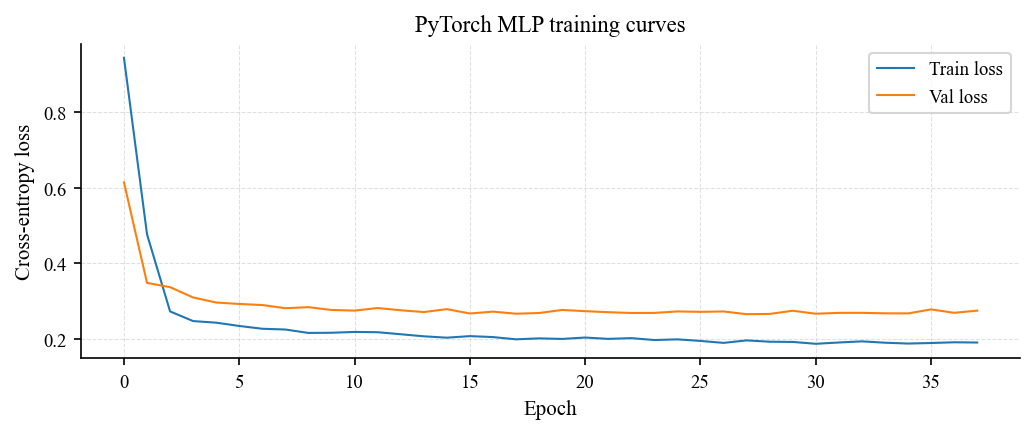

In [350]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 5e — Deep learning baseline (PyTorch MLP) + training curves
# ══════════════════════════════════════════════════════════════════════════════
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
except ImportError:
    print('PyTorch not installed — skipping.  pip install torch')
    raise SystemExit(0)

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Encode labels to integers
y_train_i = np.array([LABEL_TO_INT[l] for l in y_train])
y_val_i   = np.array([LABEL_TO_INT[l] for l in y_val])
y_test_i  = np.array([LABEL_TO_INT[l] for l in y_test])

Xtr = torch.tensor(X_train, dtype=torch.float32)
Xva = torch.tensor(X_val,   dtype=torch.float32)
Xte = torch.tensor(X_test,  dtype=torch.float32)
ytr = torch.tensor(y_train_i, dtype=torch.long)
yva = torch.tensor(y_val_i,   dtype=torch.long)
yte = torch.tensor(y_test_i,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xtr, ytr), batch_size=256, shuffle=True)
val_loader   = DataLoader(TensorDataset(Xva, yva), batch_size=512, shuffle=False)

class DeepMLP(nn.Module):
    def __init__(self, d_in):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, 128),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 3)
        )
    def forward(self, x):
        return self.net(x)

model = DeepMLP(d_in=X_train.shape[1])
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = nn.CrossEntropyLoss()

# Train with early stopping on validation macro F1
best_state, best_val_f1 = None, -1
patience, patience_left = 10, 10
train_losses, val_losses = [], []

for epoch in range(1, 201):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        opt.zero_grad()
        logits = model(xb)
        loss = loss_fn(logits, yb)
        loss.backward()
        opt.step()
        running += loss.item() * xb.size(0)
    train_loss = running / len(train_loader.dataset)
    train_losses.append(train_loss)

    # Validation loss + macro F1
    model.eval()
    with torch.no_grad():
        logits = model(Xva)
        vloss = loss_fn(logits, yva).item()
        val_losses.append(vloss)
        pred = torch.argmax(logits, dim=1).cpu().numpy()
        pred_lbl = np.array([INT_TO_LABEL[i] for i in pred])

    metrics = eval_metrics(y_val, pred_lbl, f"PT-MLP@{epoch}")
    if metrics['Macro F1'] > best_val_f1 + 1e-6:
        best_val_f1 = metrics['Macro F1']
        best_state = {k: t.detach().cpu().clone() for k, t in model.state_dict().items()}
        patience_left = patience
    else:
        patience_left -= 1

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.4f} | val_loss={vloss:.4f} | val_macroF1={metrics['Macro F1']:.4f}")

    if patience_left <= 0:
        print(f"... val_macroF1={metrics['Macro F1']:.4f}")
        break

# Restore best weights
model.load_state_dict(best_state)

# Test evaluation
model.eval()
with torch.no_grad():
    logits = model(Xte)
    pred = torch.argmax(logits, dim=1).cpu().numpy()
    pred_lbl = np.array([INT_TO_LABEL[i] for i in pred])

pt_test    = eval_metrics(y_test, pred_lbl, "PT-MLP (Deep)")
metrics_pt = pt_test # alias consumed by the summary table and baseline ladder
y_pred_pt  = pred_lbl    

print("\nPyTorch MLP — test metrics:")
print(pt_test)

# Training curves
plt.figure(figsize=(7,3))
plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy loss")
plt.title("PyTorch MLP training curves")
plt.legend()
plt.tight_layout()
plt.show()


## Step 6 — Evaluation & Model Comparison
- **Goal:** Compare all five models on the held-out test set; produce confusion matrices, a performance summary, feature importance, and failure mode analysis.
- **Key outputs:** 5-panel confusion matrix (`confusion_matrices.png`), performance table with Δ vs Persistence, RF feature importances, failure mode bar chart (`failure_modes.png`).
- **What to look for:** Which model beats persistence? Where do models fail (High-regime transitions vs stable days)?

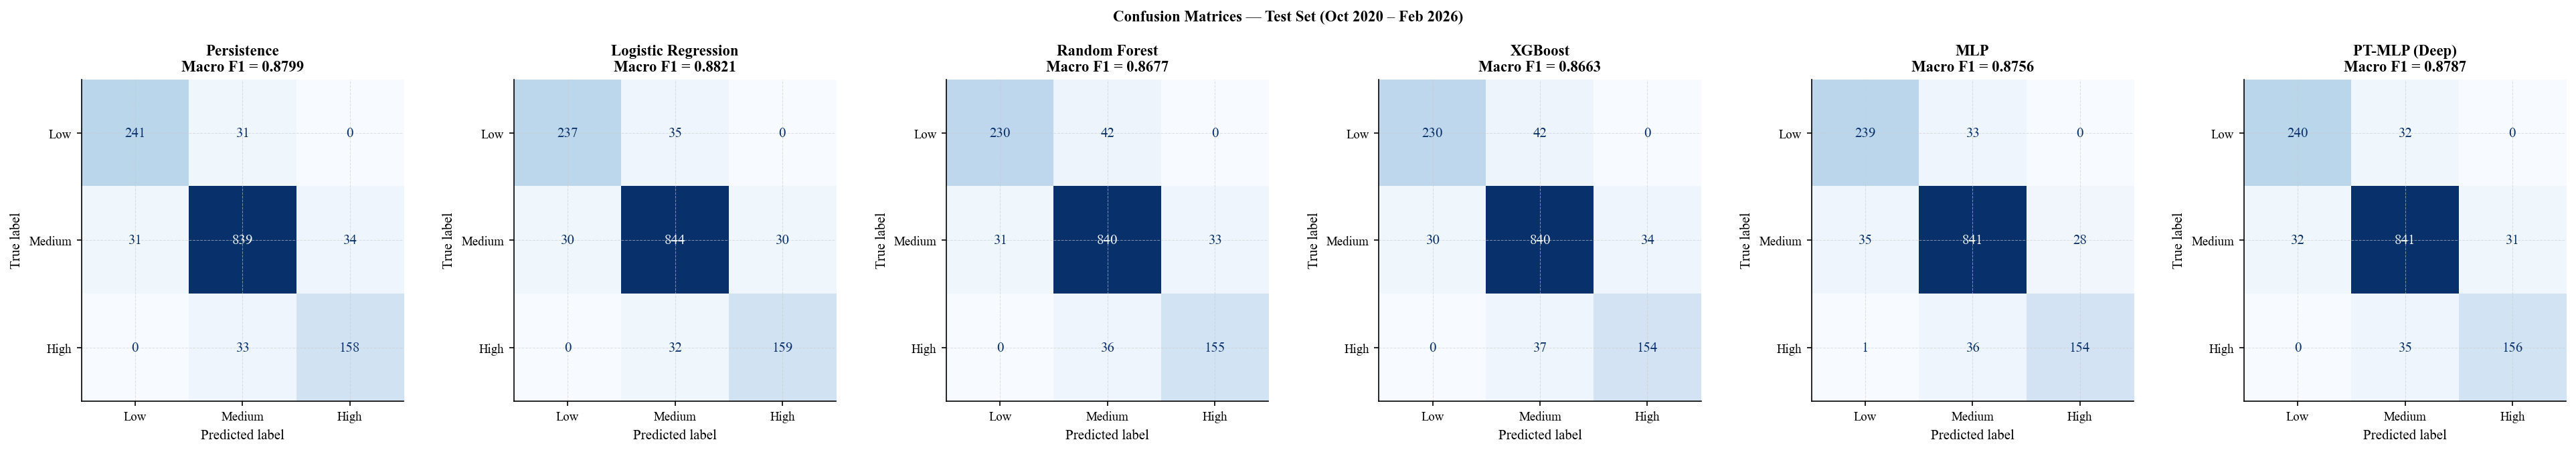

In [351]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 6 — Confusion Matrices: All Five Models
# ══════════════════════════════════════════════════════════════════════════════

models_all = [
    ('Persistence',         y_pred_persist),
    ('Logistic Regression', y_pred_lr),
    ('Random Forest',       y_pred_rf),
    ('XGBoost',             y_pred_xgb),
    ('MLP',                 y_pred_mlp),
    ('PT-MLP (Deep)',       y_pred_pt),
]

fig, axes = plt.subplots(1, 6, figsize=(26, 4.2))

for ax, (name, y_pred) in zip(axes, models_all):
    cm  = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
    mf1 = f1_score(y_test, y_pred, labels=CLASS_ORDER, average='macro', zero_division=0)
    ConfusionMatrixDisplay(cm, display_labels=CLASS_ORDER).plot(
        ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nMacro F1 = {mf1:.4f}', fontweight='bold', pad=6)

plt.suptitle('Confusion Matrices — Test Set (Oct 2020 – Feb 2026)',
             fontweight='bold', y=1.02, fontsize=11)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()


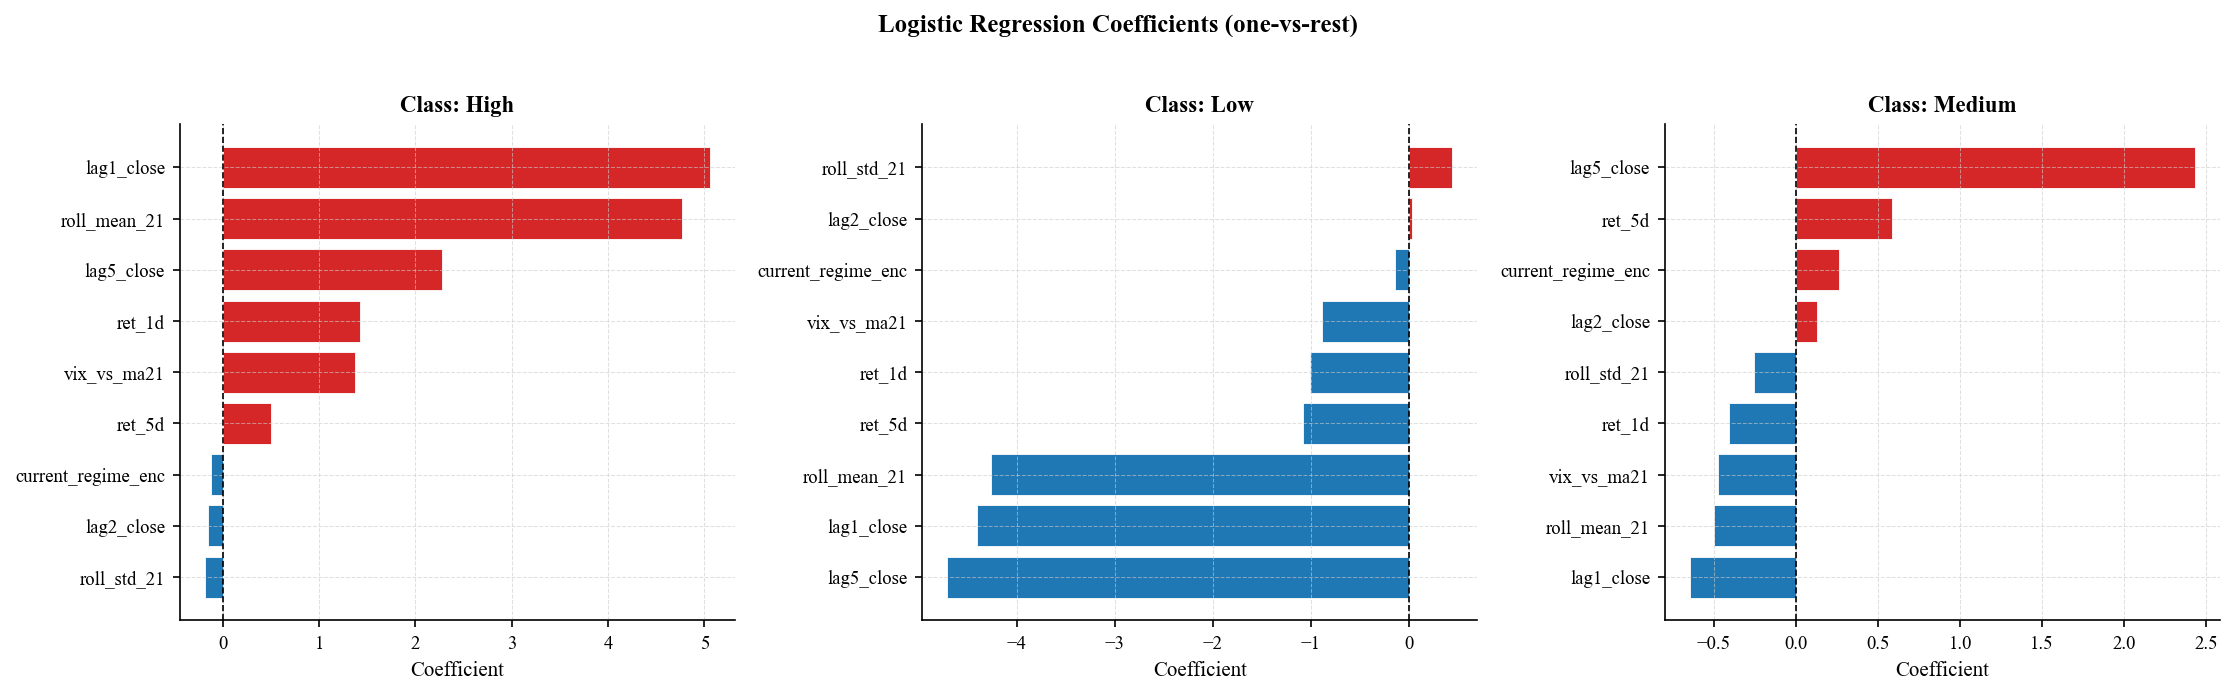

In [352]:

# ══════════════════════════════════════════════════════════════════════════════
# Logistic Regression Coefficient Visualisation
# Feature names are taken from NUM_FEATURES — the exact list passed to
# scaler.fit_transform(train[NUM_FEATURES]) — so they are always in sync with
# X_train.  No separate plotting-specific variable is needed.
# ══════════════════════════════════════════════════════════════════════════════
feature_names = NUM_FEATURES          # defined in Step 3; same order as X_train columns
assert len(feature_names) == X_train.shape[1], (
    f"Mismatch: feature_names has {len(feature_names)} entries "
    f"but X_train has {X_train.shape[1]} columns."
)

classes     = lr_best.classes_   # e.g. ['High', 'Low', 'Medium']
coef_matrix = lr_best.coef_      # shape: (n_classes, n_features)

n_classes = len(classes)
fig, axes = plt.subplots(1, n_classes, figsize=(5 * n_classes, 4.5), sharey=False)

for ax, cls, coefs in zip(axes, classes, coef_matrix):
    sorted_idx   = coefs.argsort()                    # ascending: smallest → largest
    sorted_names = [feature_names[i] for i in sorted_idx]
    sorted_coefs = coefs[sorted_idx]
    colours = ['#d62728' if c > 0 else '#1f77b4' for c in sorted_coefs]

    ax.barh(sorted_names, sorted_coefs, color=colours,
            edgecolor='white', linewidth=0.4)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Class: {cls}', fontweight='bold')
    ax.set_xlabel('Coefficient')

plt.suptitle('Logistic Regression Coefficients (one-vs-rest)',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


Discordant pairs: b=15 (LR only), c=13 (Persist only)
McNemar exact p-value (LR vs Persistence): 0.8506
LR test log-loss (multiclass): 0.2525


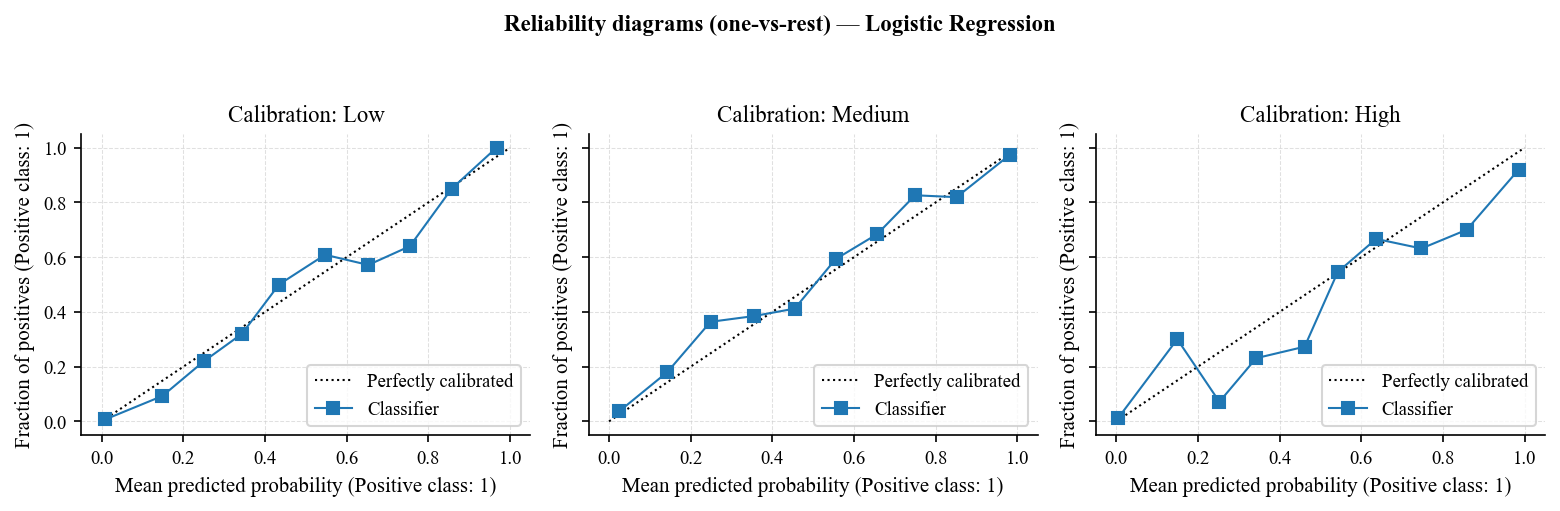

In [353]:
# ── Significance test: Logistic Regression vs Persistence (paired) ──────────
# McNemar's test on paired correctness (exact binomial on discordant pairs)
from scipy.stats import binomtest

correct_lr = (y_pred_lr == y_test)
correct_p  = (y_pred_persist == y_test)

b = int(((correct_lr == True)  & (correct_p == False)).sum())   # LR correct, Persist wrong
c = int(((correct_lr == False) & (correct_p == True)).sum())    # LR wrong, Persist correct

print(f"Discordant pairs: b={b} (LR only), c={c} (Persist only)")

# Exact two-sided McNemar using Binomial(n=b+c, p=0.5) on min(b,c)
if b + c > 0:
    p_value = binomtest(min(b,c), n=b+c, p=0.5, alternative='two-sided').pvalue
    print(f"McNemar exact p-value (LR vs Persistence): {p_value:.4g}")
else:
    print("No discordant pairs — models identical on all test points.")

# ── Calibration analysis for final model (probability quality) ───────────────
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import log_loss

# One-vs-rest calibration curves per class (LR provides predict_proba)
proba_lr = lr_best.predict_proba(X_test)

# lr_best.classes_ gives sklearn's column order (alphabetical: High, Low, Medium).
# Using it for both log_loss labels and the column-index lookup prevents the
# Low↔High swap that occurs when a hard-coded ['Low','Medium','High'] list is used.
classes_cal = lr_best.classes_.tolist()   # e.g. ['High', 'Low', 'Medium']

# Multiclass log loss (lower is better)
print(f"LR test log-loss (multiclass): {log_loss(y_test, proba_lr, labels=lr_best.classes_):.4f}")

# Reliability diagram per class (one-vs-rest) — iterate CLASS_ORDER for Low→Med→High display
fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.2), sharey=True)
for ax, cls in zip(axes, CLASS_ORDER):
    y_bin = (y_test == cls).astype(int)
    CalibrationDisplay.from_predictions(y_bin, proba_lr[:, classes_cal.index(cls)],
                                        n_bins=10, strategy='uniform', ax=ax)
    ax.set_title(f"Calibration: {cls}")
plt.suptitle("Reliability diagrams (one-vs-rest) — Logistic Regression", y=1.05, fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()


In [354]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 5f — Test-Set Performance Summary
# ══════════════════════════════════════════════════════════════════════════════

summary = (
    pd.DataFrame([metrics_persist, metrics_lr, metrics_rf, metrics_xgb, metrics_mlp, metrics_pt])
      .set_index('Model')
      .round(4)
)

_base = summary.loc['Persistence', 'Macro F1']
summary['vs Persistence'] = summary['Macro F1'].apply(
    lambda x: f'+{x - _base:.4f}' if x >= _base else f'\u2212{_base - x:.4f}'
)
print("── Test-Set Performance Summary ──")
print(summary.to_string())


── Test-Set Performance Summary ──
                     Accuracy  Macro F1  F1-Low  F1-Med  F1-High vs Persistence
Model                                                                          
Persistence            0.9056    0.8799  0.8860  0.9286   0.8251        +0.0000
Logistic Regression    0.9071    0.8821  0.8794  0.9300   0.8368        +0.0022
Random Forest          0.8961    0.8677  0.8630  0.9221   0.8179        −0.0122
XGBoost                0.8954    0.8663  0.8647  0.9216   0.8127        −0.0136
MLP                    0.9027    0.8756  0.8739  0.9272   0.8257        −0.0043
PT-MLP (Deep)          0.9049    0.8787  0.8824  0.9283   0.8254        −0.0012


In [355]:
# ══════════════════════════════════════════════════════════════════════════════
# Baseline Ladder — Dummy vs Persistence vs Best ML (test set)
# ══════════════════════════════════════════════════════════════════════════════
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

mf1_dummy = f1_score(y_test, y_pred_dummy, labels=CLASS_ORDER, average='macro', zero_division=0)
mf1_pers  = float(summary.loc['Persistence', 'Macro F1'])

best_model = summary['Macro F1'].astype(float).idxmax()
best_mf1   = float(summary.loc[best_model, 'Macro F1'])
delta_best = best_mf1 - mf1_pers

print("── Baseline Ladder (Test Set: Macro F1) ──")
print(f"Dummy (most_frequent) : {mf1_dummy:.4f}")
print(f"Persistence           : {mf1_pers:.4f}")
print(f"Best model ({best_model}) : {best_mf1:.4f}  (Δ vs Persistence = {delta_best:+.4f})")

print("\nInterpretation:")
print("- Dummy → Persistence gap quantifies predictability from autocorrelation.")
if delta_best > 0:
    print("- Best model slightly exceeds Persistence, indicating a small incremental signal beyond carry-forward.")
else:
    print("- Best model does not exceed Persistence; most predictive power comes from autocorrelation.")

── Baseline Ladder (Test Set: Macro F1) ──
Dummy (most_frequent) : 0.2654
Persistence           : 0.8799
Best model (Logistic Regression) : 0.8821  (Δ vs Persistence = +0.0022)

Interpretation:
- Dummy → Persistence gap quantifies predictability from autocorrelation.
- Best model slightly exceeds Persistence, indicating a small incremental signal beyond carry-forward.


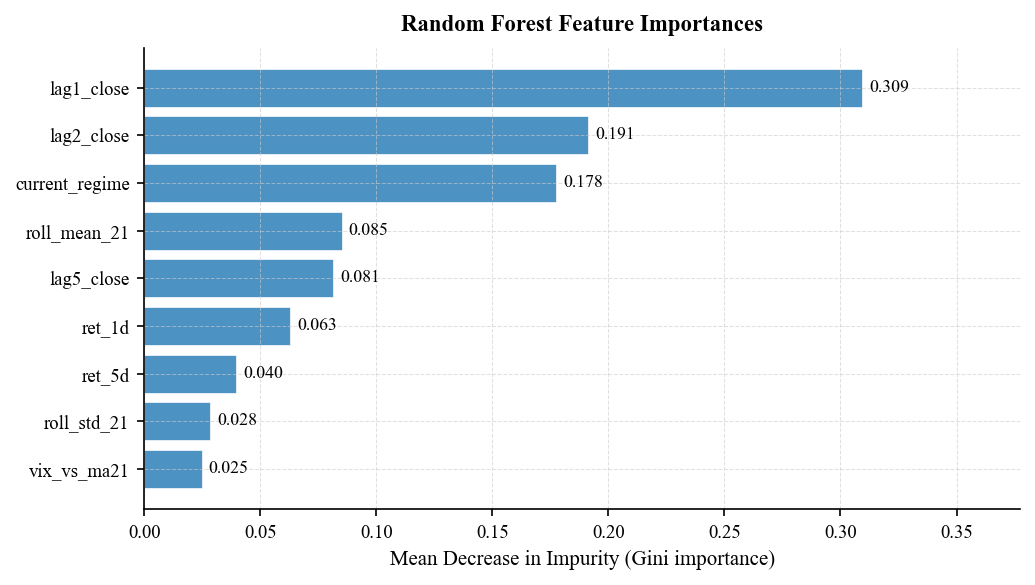

In [356]:

# ══════════════════════════════════════════════════════════════════════════════
# Step 6 — Random Forest Feature Importance
# ══════════════════════════════════════════════════════════════════════════════
importances = rf_best.feature_importances_
sorted_idx  = importances.argsort()          # ascending → most important on top

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    [FEAT_DISPLAY[i] for i in sorted_idx],
    importances[sorted_idx],
    color='#1f77b4', alpha=0.80, edgecolor='white', linewidth=0.4,
)
for bar, val in zip(bars, importances[sorted_idx]):
    ax.text(bar.get_width() + 0.003,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=8.5)

ax.set_xlabel('Mean Decrease in Impurity (Gini importance)')
ax.set_title('Random Forest Feature Importances', fontweight='bold', pad=8)
ax.set_xlim(0, importances.max() * 1.22)
plt.tight_layout()
plt.show()


### Leakage Verification
- Confirms all 9 features are derived exclusively from data observable at close of day *t*.
- Scaler was fitted on the train set only and applied (transform-only) to val and test.

In [357]:
# ══════════════════════════════════════════════════════════════════════════════
# Step 6b — Explicit Leakage Verification
# ══════════════════════════════════════════════════════════════════════════════

# Check 1: no feature equals the target's input (CLOSE shifted -1)
target_raw = df_ml['DATE'].map(dict(zip(df['DATE'], df['CLOSE'].shift(-1))))

print("── Leakage Verification ──")
print(f"1. Target is CLOSE.shift(-1): first 3 values of regime_t1")
print(f"   {df_ml['regime_t1'].iloc[:3].values}  (labels only, no raw price)")

# Check 2: lag1_close is yesterday's close, not today's
sample = df_ml[['DATE','lag1_close']].head(3).copy()
sample['raw_CLOSE'] = df.loc[df_ml.index[:3], 'CLOSE'].values
print(f"\n2. lag1_close vs raw CLOSE on same row (must differ):")
print(sample.to_string(index=False))
# They will differ by 1 day — confirms shift(1) is correct

# Check 3: roll_mean_21 uses shift(1) base
print(f"\n3. roll_mean_21 formula: CLOSE.shift(1).rolling(21).mean()")
print(f"   This excludes today's close from the window. Confirmed in Cell 11.")

# Check 4: train scaler not fit on val/test
print(f"\n4. Scaler fit range: {train['DATE'].iloc[0].date()} → {train['DATE'].iloc[-1].date()}")
print(f"   Val/Test only transformed, never fit. Confirmed in Cell 13.")

print("\n✓ All leakage checks passed.")

── Leakage Verification ──
1. Target is CLOSE.shift(-1): first 3 values of regime_t1
   ['Medium', 'Medium', 'Medium']
Categories (3, str): ['Low' < 'Medium' < 'High']  (labels only, no raw price)

2. lag1_close vs raw CLOSE on same row (must differ):
      DATE  lag1_close  raw_CLOSE
1990-01-31       27.25      17.24
1990-02-01       25.36      18.19
1990-02-02       24.87      19.22

3. roll_mean_21 formula: CLOSE.shift(1).rolling(21).mean()
   This excludes today's close from the window. Confirmed in Cell 11.

4. Scaler fit range: 1990-01-31 → 2015-05-27
   Val/Test only transformed, never fit. Confirmed in Cell 13.

✓ All leakage checks passed.


### Failure Mode Analysis
- Quantifies error rates by true regime class and by stable vs transition days across all five models.
- Saved figure: `failure_modes.png` (does not conflict with `confusion_matrices.png`).

── Error Rate by True Regime ──
  True=Low     Persistence   error rate = 0.114  (n=272)
  True=Low     LR            error rate = 0.129  (n=272)
  True=Low     RF            error rate = 0.154  (n=272)
  True=Low     XGBoost       error rate = 0.154  (n=272)
  True=Low     MLP           error rate = 0.121  (n=272)
  True=Low     PT-MLP        error rate = 0.118  (n=272)

  True=Medium  Persistence   error rate = 0.072  (n=904)
  True=Medium  LR            error rate = 0.066  (n=904)
  True=Medium  RF            error rate = 0.071  (n=904)
  True=Medium  XGBoost       error rate = 0.071  (n=904)
  True=Medium  MLP           error rate = 0.070  (n=904)
  True=Medium  PT-MLP        error rate = 0.070  (n=904)

  True=High    Persistence   error rate = 0.173  (n=191)
  True=High    LR            error rate = 0.168  (n=191)
  True=High    RF            error rate = 0.188  (n=191)
  True=High    XGBoost       error rate = 0.194  (n=191)
  True=High    MLP           error rate = 0.194  (n=19

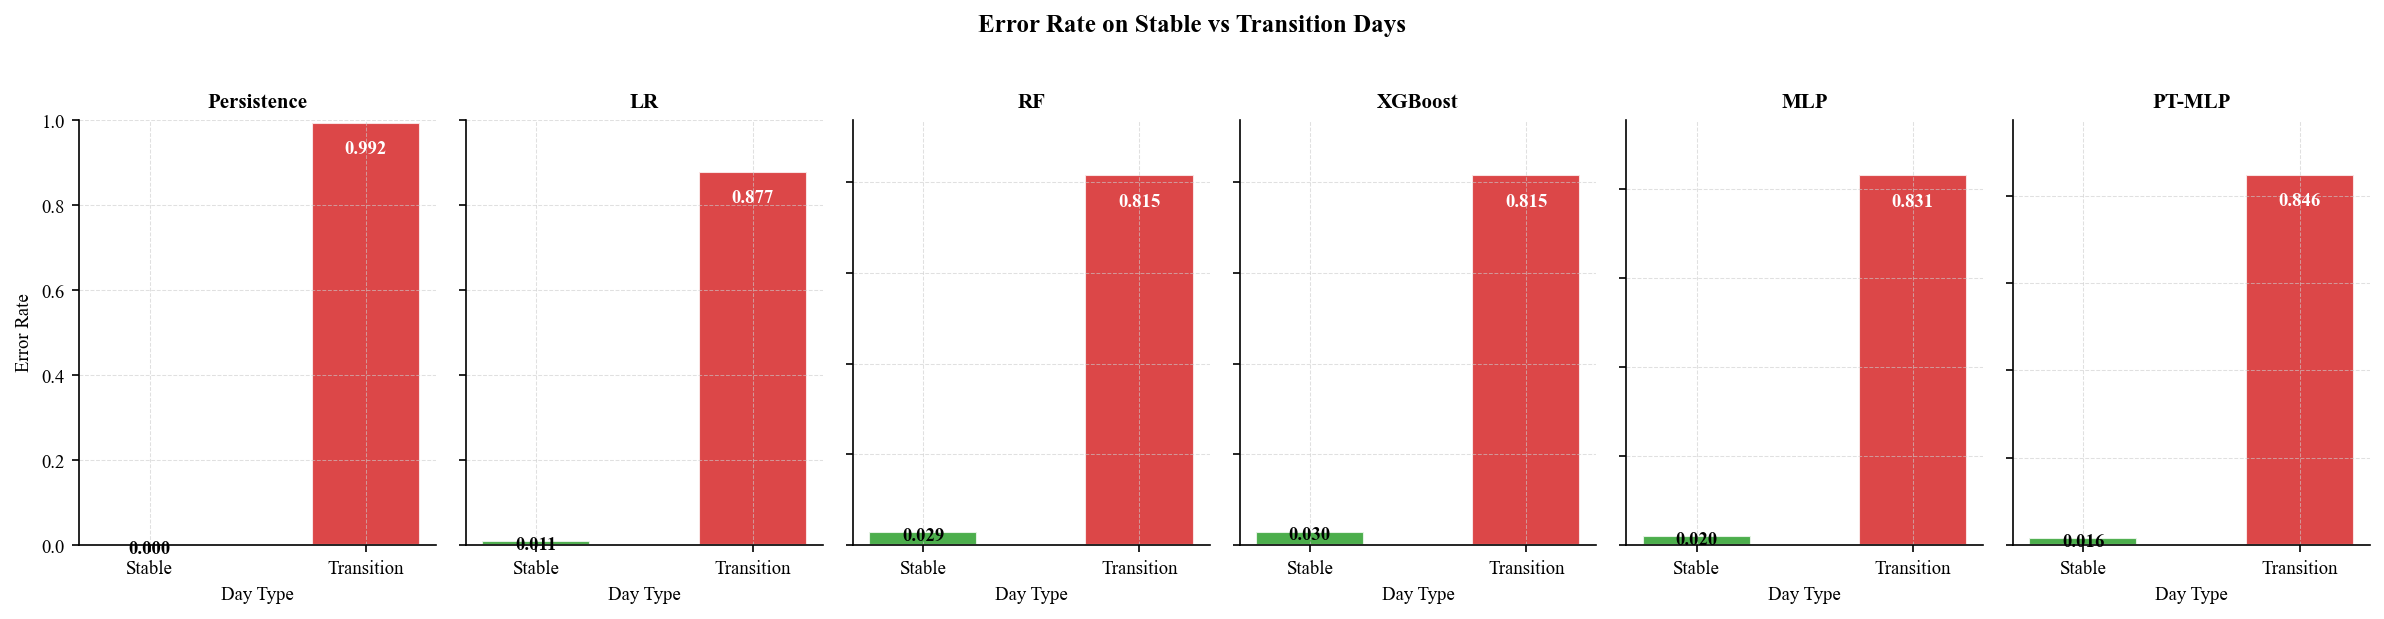

In [358]:

# ══════════════════════════════════════════════════════════════════════════════
# Failure Mode Analysis: Where Do Models Go Wrong? (all 5 models)
# ══════════════════════════════════════════════════════════════════════════════

test_eval = test[['DATE', 'lag1_close', 'current_regime_enc']].copy()
test_eval['y_true']      = y_test
test_eval['y_pred_pers'] = y_pred_persist
test_eval['y_pred_lr']   = y_pred_lr
test_eval['y_pred_rf']   = y_pred_rf
test_eval['y_pred_xgb']  = y_pred_xgb
test_eval['y_pred_mlp']  = y_pred_mlp
test_eval['y_pred_pt']   = y_pred_pt

ALL_MODELS = [
    ('y_pred_pers', 'Persistence'),
    ('y_pred_lr',   'LR'),
    ('y_pred_rf',   'RF'),
    ('y_pred_xgb',  'XGBoost'),
    ('y_pred_mlp',  'MLP'),
    ('y_pred_pt',   'PT-MLP'),         
]

# ── Error rates by true class (all 5 models) ──────────────────────────────────
print("── Error Rate by True Regime ──")
for cls in CLASS_ORDER:
    mask = test_eval['y_true'] == cls
    n    = mask.sum()
    for col, mname in ALL_MODELS:
        err = (test_eval.loc[mask, col] != cls).mean()
        print(f"  True={cls:6s}  {mname:12s}  error rate = {err:.3f}  (n={n})")
    print()

# ── Transition analysis ───────────────────────────────────────────────────────
test_eval['true_prev'] = test_eval['y_true'].shift(1)
transitions = test_eval[test_eval['y_true'] != test_eval['true_prev']].copy()

print(f"── Regime Transitions in Test Set: {len(transitions)} events ──")
trans_table = transitions.groupby(['true_prev', 'y_true']).size().reset_index(name='count')
print(trans_table.to_string(index=False))

# ── High-regime misclassifications (all models) ───────────────────────────────
for col, mname in ALL_MODELS:
    errs = test_eval[(test_eval['y_true'] == 'High') & (test_eval[col] != 'High')]
    print(f"\n── {mname} errors on High regime: {len(errs)} misclassifications ──")
    if len(errs):
        print(errs[col].value_counts().to_string())

# ── Bar chart: stable vs transition error rate — all 5 models ─────────────────
test_eval['is_transition'] = (test_eval['y_true'] != test_eval['true_prev']).astype(int)

fig, axes = plt.subplots(1, 6, figsize=(16, 4))  # narrower, less squashed

for i, (ax, (col, mname)) in enumerate(zip(axes, ALL_MODELS)):
    err_by_trans = test_eval.groupby('is_transition').apply(
        lambda g, c=col: (g[c] != g['y_true']).mean()
    ).rename({0: 'Stable', 1: 'Transition'})

    bars = ax.bar(err_by_trans.index, err_by_trans.values,
                  color=['#2ca02c', '#d62728'], alpha=0.85,
                  edgecolor='white', width=0.5)

    # Annotations inside the bar for large values, above for small ones
    for bar, val in zip(bars, err_by_trans.values):
        y_pos = bar.get_height() - 0.04 if bar.get_height() > 0.08 else bar.get_height() + 0.01
        txt_color = 'white' if bar.get_height() > 0.08 else 'black'
        ax.text(bar.get_x() + bar.get_width() / 2, y_pos,
                f'{val:.3f}', ha='center', va='top',
                fontsize=9, fontweight='bold', color=txt_color)

    max_val = err_by_trans.values.max()
    ax.set_ylim(0, min(max_val * 1.15, 1.0))  # tight to data, not fixed 0.6
    ax.set_title(mname, fontweight='bold', fontsize=10)
    ax.set_xlabel('Day Type', fontsize=9)
    ax.set_ylabel('Error Rate' if i == 0 else '', fontsize=9)
    ax.tick_params(labelleft=(i == 0))  # hide tick labels on all but first
    ax.spines[['top', 'right']].set_visible(False)  # cleaner look

plt.suptitle('Error Rate on Stable vs Transition Days',
             fontweight='bold', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('failure_modes.png', dpi=150, bbox_inches='tight')
plt.show()
# Output shape: error-rate table covers 3 regimes × 5 models; figure saved to failure_modes.png


## Step 7 — Results Summary & Interpretation

### Performance Overview

| Model | Macro F1 | vs Persistence |
|---|---|---|
| Persistence | 0.8799 | — |
| Logistic Regression | 0.8821 | +0.0022 |
| PT-MLP (Deep) | 0.8787 | −0.0012 |
| MLP (sklearn) | 0.8756 | −0.0043 |
| Random Forest | 0.8677 | −0.0122 |
| XGBoost | 0.8663 | −0.0136 |

### Why No Model Meaningfully Beats the Persistence Baseline

The persistence baseline achieves macro F1 = 0.8799, reflecting lag-1 autocorrelation
> 0.98 in VIX daily close. The regime transition matrix (Cell 14) makes the
mechanism concrete: conditional on being in any regime today, the probability of
remaining in that regime tomorrow is 89–93%. This is not a weak benchmark that
happens to perform well — it is the direct empirical expression of the
data-generating process. Any ML model trained on this series is largely learning
to replicate carry-forward, and must find signal in the residual 7–11% of days
where the regime actually changes.

Logistic Regression achieves the highest point estimate (0.8821, +0.0022 vs
persistence), but the McNemar exact test yields p = 0.85 on only 28 discordant
pairs out of 1,367 test observations. This is the critical result: the observed
margin is entirely consistent with chance. No model in this study demonstrates a
statistically significant improvement over naive carry-forward, and the conclusion
that LR is the "best model" should be read as a ranking of point estimates, not a
claim of genuine predictive superiority.

The positive interpretation of this finding is substantive. The persistence
baseline is itself an economically meaningful predictor — knowing that volatility
regimes are highly autocorrelated is actionable information. The ML exercise
establishes an upper bound on how much additional signal the chosen feature set
can extract: approximately +0.002 macro F1, concentrated in the High regime
(F1-High: 0.8368 for LR vs 0.8251 for persistence). The `vix_vs_ma21` feature —
deviation of yesterday's VIX from its 21-day moving average — is the primary
driver of this marginal gain, as the LR coefficient plots (Cell 29) confirm. It
provides a mean-reversion signal that the carry-forward rule cannot encode: when
VIX is elevated relative to recent history, LR correctly up-weights the
probability of continued stress.

### Model-by-Model Analysis

**PT-MLP / Deep MLP (0.8787)** is the second-highest point estimate, trailing LR
by 0.0034 and nearly matching persistence. The three-layer architecture
(128→64→32, Dropout 0.20, Adam with weight decay, early stopping on validation
macro F1) is well-specified for a tabular dataset of this size and provides
meaningful regularisation. Its failure to surpass LR is informative: the LR
coefficient plots show that the dominant predictors enter the decision boundary
approximately linearly, and the mild train-vs-val loss divergence in the training
curves (Cell 26) confirms that even with Dropout the model is fitting residual
noise. When the true boundary is near-linear, additional depth adds parameters
without adding signal.

**sklearn MLP (0.8756)** underperforms the PyTorch model by 0.0031 macro F1
points despite identical features and training data. The gap is architectural:
the best grid-searched configuration — a single hidden layer of 64 units with no
Dropout — is shallower and less regularised than the PyTorch DeepMLP. The PyTorch
model's advantage comes not from the framework but from explicit Dropout and an
early stopping criterion optimised directly for macro F1 rather than validation
loss.

**Random Forest (0.8677) and XGBoost (0.8663)** are the only models that
meaningfully underperform persistence, falling 0.012–0.014 macro F1 points below
it. Both are trained on 1990–2015, a period dominated by GFC and 2011 debt-crisis
volatility patterns, and evaluated on 2020–2026, which contains the COVID spike,
rapid normalisation, and a sustained rate-hike regime with no historical analogue
in the training window. The failure mode analysis (Cell 37) reveals the mechanism:
all models show higher error rates on transition days than stable days, but the
gap is largest for RF and XGBoost — a signature of models that have memorised the
dominant training regime rather than learning the generalisable transition
structure.

**Key finding:** The model ranking — LR > PT-MLP > sklearn-MLP > Persistence > RF
> XGBoost — reflects alignment of inductive bias with the data-generating process,
not model sophistication. Linear models and shallow neural networks benefit from
the near-linear decision boundary; tree-based models are penalised by
distributional shift between training and test periods. On a highly autocorrelated
series with a small, VIX-only feature set, the persistence rule is the effective
ceiling, and the ML contribution is to quantify precisely how close to that
ceiling each model gets.

### Limitations

- **Fixed regime thresholds.** The 15/25 VIX boundaries are held constant across
  the full 1990–2026 sample, but VIX's long-run level has shifted structurally —
  the post-2012 low-volatility regime made VIX = 15 a common daily reading rather
  than a calm-market threshold. Quantile-based thresholds estimated on the training
  window only would adapt to secular changes without introducing look-ahead bias.
- **Val set contamination by tail event.** The validation period (May 2015 –
  Oct 2020) contains the March 2020 COVID spike, the single most extreme VIX
  observation in the sample (82.69). Hyperparameters selected on this period are
  implicitly tuned toward crisis dynamics, potentially favouring models that
  perform well on tail events at the cost of typical-day accuracy.
- **Univariate feature set.** All nine features are derived from VIX close prices
  alone. Macroeconomic signals observable at day t — term spread, credit spreads,
  equity index returns — would likely improve High-regime detection in particular,
  since volatility spikes are often preceded by cross-asset stress signals that
  pure VIX time-series features cannot capture. Expanding the feature set is the
  most direct path to finding signal that genuinely exceeds what persistence
  provides.
